### Imports

In [25]:
import abmax.structs as abx_struct
import abmax.functions as abx_func
import jax.numpy as jnp
import jax.random as random
import jax
import numpy as np
import matplotlib.pyplot as plt
from flax import struct
from abmax.structs import *
import importlib
import benchmark_adapter
import benchmarks_2D as b2d
import benchmarks_CEC as bcec
from benchmark_adapter import get_bounds, get_objective_name, make_objective_fn
import time
import pandas as pd
import matplotlib.patches as patches
import matplotlib.patheffects as pe
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

## Defining the agents functions

In [2]:
@struct.dataclass
class Forager(abx_struct.Agent):
    @staticmethod
    def create_agent(type,params: abx_struct.Params | None,id: jnp.int32,active_state: bool,key: jax.random.PRNGKey):
        """
        Creating a single agent
        returns an agent with random position in the search space, and fitness set to infinity.
        """

        # Allows for extrenal overides, but enables the use of defined hyperparamaters if none are inputed
        incoming = {} if (params is None or not hasattr(params, "content")) else params.content
        # Sampling helper hyperparamater
        bounds = incoming["bounds"]

        # Paramaters object and agent carries agent_params
        agent_params = abx_struct.Params(content=incoming)

        # Random uniform initialization  
        # Gets number of dimensions in the search space
        d = bounds.shape[0]

        # Each agent gets different key
        lo, hi = bounds[:, 0], bounds[:, 1]
        pos = random.uniform(key, (d,), minval=lo, maxval=hi)

        # Evaluating the agents starting position when initialized placeholder
        fit_placeholder = jnp.asarray(jnp.inf, dtype=jnp.float32)

        # State 
        state_content = {
            'pos': pos,                                  # current point (real space)
            'fit': fit_placeholder,                                  # fitnnes
            'best_pos': pos,                             # personal best position
            'best_fit': fit_placeholder,                             # personal best fitnnes
            'evals': jnp.asarray(0, jnp.int32),          # number of evaluations of the current position the agent has done
        }
        # States which agent carries
        agent_state = abx_struct.State(content=state_content)   
        
        return Forager(params=agent_params,id=id,state=agent_state,agent_type=type,key=key,policy=None,age=jnp.asarray(0.0, jnp.float32),active_state=active_state)
    
    @staticmethod
    def create_agent_at_pos(type,params: abx_struct.Params | None,id: jnp.int32, active_state: bool,key: jax.random.PRNGKey, pos: jnp.ndarray):
        """
        Creating a single agent at a given position
        Returns an agent at a given position in the search space, and fitness set to infinity.
        """

        # Allows for extrenal overides, but enables the use of defined hyperparamaters if none are inputed
        incoming = {} if (params is None or not hasattr(params, "content")) else params.content

        # Paramaters object and agent carries agent_params
        agent_params = abx_struct.Params(content=incoming)

        # Evaluating the agents starting position when initialized
        fit_placeholder = jnp.asarray(jnp.inf, dtype=jnp.float32)

        # State 
        state_content = {
            'pos': pos,                                  # current point (real space)
            'fit': fit_placeholder,                                  # fitnnes
            'best_pos': pos,                             # personal best position
            'best_fit': fit_placeholder,                             # personal best fitnnes
            'evals': jnp.asarray(0, jnp.int32),          # number of evaluations of the current position the agent has done
        }
        # States which agent carries
        agent_state = abx_struct.State(content=state_content)  
        return Forager(params=agent_params,id=id,state=agent_state,agent_type=type,key=key,policy=None,age=jnp.asarray(0.0, jnp.float32),active_state=active_state)
    
    @staticmethod
    def sort_agents_by_fitness(agents):
        """
        Sort agents in ascending order of fitness.
        (Best agent first, worst agent last.)

        Args:
            agents: batched Agent/Forager pytree .

        Returns:
            agents_sorted: same structure, sorted by fitness.
            sorted_idx:   indices such that fitness[sorted_idx] is ascending.
        """
        # Getting fitness values
        fit_all = agents.state.content["fit"]
        # Flattening fitness to 1D array
        quantity = jnp.reshape(fit_all, (-1,))
        # Sorting ascending order
        sorted_idx = jnp.argsort(quantity)
        # Generating sorted agents
        agents_sorted = jax.tree_util.tree_map(lambda x: jnp.take(x, sorted_idx, axis=0), agents)

        return agents_sorted, sorted_idx

## Initialization functions

In [3]:

def evaluate_positions(pos: jnp.ndarray, objective_fn) -> jnp.ndarray:
    """
    Vectorized objective evaluation.
    """
    fit = jax.vmap(objective_fn)(pos)
    return fit.astype(jnp.float32)

def initialize_fitness_in_agents(agents, fit: jnp.ndarray,*, set_best: bool,set_evals_to: int | None):
    """
    Set fitness values in agents'state, used in initialization
    step of the algorithm.
    Returns updated agents with fitness set, and optionally also best fitness/pos and evals.
     """
    state = dict(agents.state.content)  
    state["fit"] = fit

    if set_best:
        state["best_fit"] = fit
        state["best_pos"] = state["pos"]  # whatever the agent currently stores as pos

    if set_evals_to is not None:
        N = state["pos"].shape[0]  # number of agents
        state["evals"] = jnp.full((N,), set_evals_to, dtype=jnp.int32)

    return agents.replace(state=agents.state.replace(content=state))

def init_random_agents(key, *, num_agents: int, agent_type: jnp.ndarray, agent_params, objective_fn):
    """
    Randomly generating N agents ia a vectorized way, then explicitly evaluating fitness and writing it back.

    Returns:
      key, agents, ids
    """
    # Creating ids and active flags for agents
    ids = jnp.arange(num_agents, dtype=jnp.int32)
    active = jnp.ones(num_agents, dtype=bool)

    # Split key into one subkey per agent
    key, key_agents = random.split(key)
    subkeys = jax.vmap(lambda i: random.fold_in(key_agents, i))(ids)

    # Creating agents
    agents = jax.vmap(Forager.create_agent, in_axes=(None, None, 0, 0, 0))(agent_type, agent_params, ids, active, subkeys)

    # Extracting positions and fitnesses from the batched agents
    pos = agents.state.content["pos"]
    fit = evaluate_positions(pos, objective_fn)

    # Writing back evaluated fitness into agents state
    agents = initialize_fitness_in_agents(agents, fit, set_best=True, set_evals_to=1)

    return key, agents, ids

def init_qop_agents(key,*, agents, ids_base: jnp.ndarray, lo: jnp.ndarray, hi: jnp.ndarray, agent_type: jnp.ndarray, agent_params, objective_fn):
    """
    Generating quasi-opposite positions from original pos, create N quasi agents at those positions,
       then explicitly evaluate fitness and write it back.

    Returns:
      key, agents_qop
    
    """
    # Extracting positions from the original agents
    pos = agents.state.content["pos"]
    # Bounds and center
    center = (lo + hi) / 2.0
    # Finding oposite position for each agent
    pos_op = lo + hi - pos

    # Generating quasi opposite position - random uniform sampling between center and pos_op
    key, key_q = random.split(key)
    u = random.uniform(key_q, shape=pos.shape)
    q_low = jnp.minimum(center, pos_op)
    q_high = jnp.maximum(center, pos_op)
    pos_qop = q_low + u * (q_high - q_low)

    # Quasi agent ids: offset by N
    num_agents = ids_base.shape[0]
    ids_qop = ids_base + num_agents
    active_qop = jnp.ones(num_agents, dtype=bool)

    # Random keys for quasi agents
    key, key_q_agents = random.split(key)
    subkeys_q = jax.vmap(lambda i: random.fold_in(key_q_agents, i))(ids_qop)

    # Creating quasi agents 
    agents_qop = jax.vmap(Forager.create_agent_at_pos, in_axes=(None, None, 0, 0, 0, 0))(agent_type, agent_params, ids_qop, active_qop, subkeys_q, pos_qop)

    # Evaluation step for quasi agents
    fit_qop = evaluate_positions(pos_qop, objective_fn)
    agents_qop = initialize_fitness_in_agents(agents_qop, fit_qop, set_best=True, set_evals_to=1)

    return key, agents_qop

def select_best_half_after_qobl(agents, agents_qop):
    """
    Combining original + quasi agents, sort by fitness ascending, keep best N/2.
    Returns the kept agents, and their origin flags (0=original, 1=quasi).
    """
    num_agents = agents.state.content["fit"].shape[0] # number of original agents (N)

    # Combining original and quasi-opposite agents into a single population
    agents_all = jax.tree_util.tree_map(lambda a, b: jnp.concatenate([a, b], axis=0), agents, agents_qop)

    # 0 = original, 1 = quasi
    origin_flags_all = jnp.concatenate([jnp.zeros(num_agents, dtype=jnp.int32), jnp.ones(num_agents, dtype=jnp.int32)],axis=0)

    # Sort all 2N agents by fitness (ascending)
    agents_sorted, sorted_idx = Forager.sort_agents_by_fitness(agents_all)
    origin_sorted = origin_flags_all[sorted_idx]

    # Keep only the best half
    M = agents_sorted.state.content["fit"].shape[0]   # should be 2N
    M_keep = M // 2                                   # N

    agents_init = jax.tree_util.tree_map(lambda x: x[:M_keep], agents_sorted)
    origin_init = origin_sorted[:M_keep]

    return agents_init, origin_init

def init_population_qobl(key,*, num_agents: int, agent_type: jnp.ndarray, agent_params, objective_fn, bounds: jnp.ndarray):
    """
    Wrapper function to initialize population with QOBL
    
    Returns:
      key, agents_init, origin_init
    """
    lo, hi = bounds[:, 0], bounds[:, 1]
    # Initializing random agents
    key, agents, ids = init_random_agents(key, num_agents=num_agents, agent_type=agent_type, agent_params=agent_params, objective_fn=objective_fn)
    # Initializing quasi-opposite agents
    key, agents_qop = init_qop_agents(key, agents=agents, ids_base=ids, lo=lo, hi=hi, agent_type=agent_type, agent_params=agent_params, objective_fn=objective_fn)
    # Selecting best half after QOBL
    agents_init, origin_init = select_best_half_after_qobl(agents, agents_qop)
    
    return key, agents_init, origin_init

## Algortihm main part functions

In [4]:
def acceptance_rule_mask(key, *, fit_parent, fit_offspring, t):
    """
    Step (2-3): sample λ^{t+1} and compute Eq. (2) accept/reject mask.

    Returns: key_new, accept
    """
    # Choose whether to accept offspring or not (Eq. 2)
    key, key_lambda = random.split(key)
    lambda_t1 = random.uniform(key_lambda, shape=fit_parent.shape, minval=0.0, maxval=1.0, dtype=jnp.float32)

    t = jnp.float32(t)  # current iteration 
    # Acceptance condition equation
    off_side = (lambda_t1 * fit_offspring) / (1.0 + (t + 1.0) * lambda_t1)
    parent_side = fit_parent / t

    accept = off_side < parent_side   # Boolean mask: True => offspring selected
    return key, accept

def apply_acceptance_update(agents_sorted, *, pos_offspring, fit_offspring, accept):
    """
    Step (2-4): merge preserved solutions into next population (state update only).
    Returns updated agents with new positions, fitness, and personal bests.
    """
    pos_parent = agents_sorted.state.content["pos"]      
    fit_parent = agents_sorted.state.content["fit"]        
    best_pos   = agents_sorted.state.content["best_pos"]  
    best_fit   = agents_sorted.state.content["best_fit"]   
    evals      = agents_sorted.state.content["evals"]      

    # Updating agent positions and fitness based on acceptance
    pos_new = jnp.where(accept[:, None], pos_offspring, pos_parent)   # (N, D) choosing new positions
    fit_new = jnp.where(accept,         fit_offspring, fit_parent)    # (N,) choosing new fitness
    
    # Update evaluation counters: one offspring fitness evaluation per agent
    evals_new = evals + jnp.int32(1)

    # Personal best update if improved
    improved_best = fit_new < best_fit
    best_fit_new = jnp.where(improved_best, fit_new, best_fit)
    best_pos_new = jnp.where(improved_best[:, None], pos_new, best_pos)

    # Write back immutably
    state = dict(agents_sorted.state.content)
    state["pos"] = pos_new
    state["fit"] = fit_new
    state["evals"] = evals_new
    state["best_fit"] = best_fit_new
    state["best_pos"] = best_pos_new

    agents_new = agents_sorted.replace(state=agents_sorted.state.replace(content=state))
    return agents_new

def sort_last_iteration(agents, t, T):
    """
    Sort agents only if t == T, otherwise return agents unchanged.
    Returns sorted agents at the last iteration, or original agents if not the last iteration.
    """

    def sorted_agents(a):
        a_sorted, _ = Forager.sort_agents_by_fitness(a)
        return a_sorted

    def original(a):
        return a

    return jax.lax.cond(t == T, sorted_agents, original, agents)

def cosine_k(t, T):
    """
    Cosine-based scale factor from the QOS-OFA paper:
      K(t) = cos( (pi/2) * (t/T) )
    We use (t-1)/T-1 for correct start.
    Returns the scale factor K for iteration t given total iterations T.
    """
    tt = (t - 1) / (T - 1) # Formula
    return jnp.cos(0.5 * jnp.pi * tt)

def repair_out_of_bounds_uniform(key, pos, lo, hi):
    """
    Repair out-of-bounds coordinates by resampling uniformly within bounds.
    """
    key, subkey = random.split(key)

    rand_pos = random.uniform(subkey, shape=pos.shape, minval=lo, maxval=hi, dtype=pos.dtype)

    mask = (pos < lo) | (pos > hi)
    repaired_pos = jnp.where(mask, rand_pos, pos)

    return key, repaired_pos

def generate_agent_positions(key, pos_sorted, lo, hi, k):
    """
    Generate new positions for QOS-OFA.

    """
    N = pos_sorted.shape[0]
    D = pos_sorted.shape[1]

    # Extracting best and worst positions from the sorted population
    x_best = pos_sorted[0]
    x_worst = pos_sorted[-1]

    key, k_r1, k_r2, k_b, k_r = random.split(key, 5)
    
    # Sampling random factors for recruitment and social steps
    r1 = random.uniform(k_r1, shape=(N, D), dtype=pos_sorted.dtype)
    r2 = random.uniform(k_r2, shape=(N, D), dtype=pos_sorted.dtype)
    
    # Compute delta for recruitment step
    delta = r1 - r2
    # Agent indices for sampling x_b and x_r
    j_idx = jnp.arange(N, dtype=jnp.int32)

    # Sampling indices for x_b and x_r
    u_b = random.uniform(k_b, shape=(N,), dtype=pos_sorted.dtype)

    b_max = jnp.maximum(j_idx, 1)
    b = jnp.floor(u_b * b_max.astype(pos_sorted.dtype)).astype(jnp.int32)
    b = jnp.clip(b, 0, N - 1)
    # Get x_b for each agent based on sampled indices
    x_b = pos_sorted[b]
    # Sampling indices for x_r
    u_r = random.uniform(k_r, shape=(N,), dtype=pos_sorted.dtype)

    r = jnp.floor(u_r * jnp.asarray(N, dtype=pos_sorted.dtype)).astype(jnp.int32)
    r = jnp.clip(r, 0, N - 1)

    x_r = pos_sorted[r]
    
    # Best agent special case
    recruitment_best_step = k * delta[0] * (x_best - x_worst)
    social_best_step = jnp.zeros((D,), dtype=pos_sorted.dtype)

    # Other agents
    recruitment_non_best_step = k * delta * (pos_sorted - x_b)
    social_non_best_step = (1.0 - k) * (x_best - x_r)

    is_best = j_idx == 0

    # Combine best and non-best recruitmentsteps using the is_best mask
    recruitment_step = jnp.where(is_best[:, None], recruitment_best_step[None, :], recruitment_non_best_step)
    # Combine best and non-best social steps using the is_best mask
    social_step = jnp.where(is_best[:, None], social_best_step[None, :], social_non_best_step)
    # New position proposal
    proposed_position = pos_sorted + recruitment_step + social_step
    # Repairing out-of-bounds proposed positions
    key, pos_offspring = repair_out_of_bounds_uniform(key, proposed_position, lo, hi)

    return key, pos_offspring, recruitment_step, social_step

def one_iteration(carry, t):
    """
    One iteration of the QOS-OFA algorithm, as described in the paper.
    Returns the updated carry with new population, and an output tuple for debugging/analysis.
    """
    # Carry maintains the RNG key and the current population of agents
    key, agents, objective_fn, lo, hi, T = carry

    # Sorting agents 
    agents_sorted, _ = Forager.sort_agents_by_fitness(agents)

    # Extract parent positions/fitness 
    pos_parent = agents_sorted.state.content["pos"]   
    fit_parent = agents_sorted.state.content["fit"]   

    # Cosine scale factor K(t)
    k = cosine_k(t, T)

    # Generate offspring positions 
    key, pos_offspring, recruitment_step, social_step = generate_agent_positions(key, pos_parent, lo, hi, k)
    
    # Evaluate offspring fitness
    fit_offspring = evaluate_positions(pos_offspring, objective_fn)

    # Eq. (2) accept/reject
    key, accept = acceptance_rule_mask(key, fit_parent=fit_parent, fit_offspring=fit_offspring, t=t)

    # Merging new positions and fitness into next population
    agents_new = apply_acceptance_update(agents_sorted, pos_offspring=pos_offspring, fit_offspring=fit_offspring, accept=accept)

    # Sorting agents at the last iteration for final output, only if t == T
    agents_final = sort_last_iteration(agents_new, t, T)

    # Carry forward updated population
    carry_new = (key, agents_final, objective_fn, lo, hi, T)

    # For debbuging
    out = (pos_parent, fit_parent, pos_offspring, fit_offspring, accept, k, recruitment_step, social_step)
    return carry_new, out

def make_one_iteration(objective_fn):
    """
    Creates one QOS-OFA iteration with objective_fn fixed by closure.

    objective_fn is a callable:
        objective_fn(x) -> scalar fitness
    """

    def one_iteration_wrapped(carry, t):
        key, agents, lo, hi, T = carry

        # Sort agents
        agents_sorted, _ = Forager.sort_agents_by_fitness(agents)

        pos_parent = agents_sorted.state.content["pos"]
        fit_parent = agents_sorted.state.content["fit"]

        # Compute k schedule
        k = cosine_k(t, T)

        # Generate offspring positions
        key, pos_offspring, recruitment_step, social_step = generate_agent_positions(key, pos_parent, lo, hi,k)

        # Evaluate offspring using objective_fn
        fit_offspring = evaluate_positions(pos_offspring, objective_fn)

        # Acceptance
        key, accept = acceptance_rule_mask(key, fit_parent=fit_parent, fit_offspring=fit_offspring, t=t)

        # Apply accepted offspring
        agents_new = apply_acceptance_update(agents_sorted, pos_offspring=pos_offspring, fit_offspring=fit_offspring, accept=accept)

        # Sort if needed
        agents_final = sort_last_iteration(agents_new, t, T)

        carry_new = (key, agents_final, lo, hi, T)

        # For debbuging
        out = (pos_parent, fit_parent, pos_offspring, fit_offspring, accept, k, recruitment_step, social_step)

        return carry_new, out

    return one_iteration_wrapped

def run_with_termination(key, agents_init, objective_fn, lo, hi, T):
    """
    Runs the QOS-OFA algorithm for T iterations, starting from agents_init, and returns the final population and all outputs across iterations.
    """
    carry0 = (key, agents_init, lo, hi, T)

    # termination state
    ts = jnp.arange(1, T + 1, dtype=jnp.int32) # iteration numbers from 1 to T
    one_it = make_one_iteration(objective_fn)
    carryT, outs = jax.lax.scan(one_it, carry0, ts) # scan over iterations, carryT is final carry, outs is all outputs


    keyT, agentsT, _, _, _ = carryT # unpacking final carry, we only care about key and agents for output
    return keyT, agentsT, outs

# Experiment runner functions

In [5]:
def get_cec_bias(objective_id: int, dim: int = 30) -> float:
    """
    Return the known CEC optimum/bias for the selected CEC objective.
    """
    params = bcec.get_cec_params(dim=dim)
    return float(params[objective_id]["bias"])

def run_single_experiment(*, benchmark_family: str, objective_id: int, T: int, num_agents: int, seed: int, dim=None, agent_type=jnp.int16(0), return_details: bool = False):
    """
    Run original QOS-OFA once on one selected benchmark.

    Supports:
    - benchmark_family="2d"
    - benchmark_family="cec"
    """

    # Benchmark setup
    bounds = get_bounds(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)

    objective_fn = make_objective_fn(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)

    lo, hi = bounds[:, 0], bounds[:, 1]
    agent_params = abx_struct.Params(content={"bounds": bounds})

    # Random key
    key = random.PRNGKey(seed)

    t0 = time.perf_counter()

    # QOBL initialization
    key, agents_init, origin_init = init_population_qobl(key, num_agents=num_agents, agent_type=agent_type, agent_params=agent_params, objective_fn=objective_fn, bounds=bounds)

    initial_best = float(agents_init.state.content["fit"][0])

    # Main optimization loop
    key, agentsT, outs = run_with_termination(key, agents_init, objective_fn, lo, hi, T=T)
    runtime_sec = time.perf_counter() - t0

    final_best = float(agentsT.state.content["fit"][0])
    best_position = np.array(agentsT.state.content["pos"][0])

    # CEC error
    if benchmark_family == "cec":
        params = bcec.get_cec_params(dim=dim)
        cec_func_num = int(params[objective_id]["func_num"])
        bias = float(params[objective_id]["bias"])
        cec_error = final_best - bias
    else:
        cec_func_num = None
        bias = None
        cec_error = None

    # Effective fitness evaluations
    # QOBL evaluates N random + N quasi-opposite, then N offspring per iteration.
    reported_nfes = T * num_agents          # paper-style main-loop budget
    init_nfes = 2 * num_agents              # QOBL initialization evaluations
    strict_total_nfes = init_nfes + reported_nfes 

    result = {
        "benchmark_family": benchmark_family,
        "objective_id": objective_id,
        "objective_name": get_objective_name(benchmark_family, objective_id),
        "cec_func_num": cec_func_num,
        "dim": dim,
        "T": T,
        "num_agents": num_agents,
        "seed": seed,
        "initial_best": initial_best,
        "final_best": final_best,
        "cec_bias": bias,
        "cec_error": cec_error,
        "runtime_sec": runtime_sec,
        "reported_nfes": reported_nfes,
        "init_nfes": init_nfes,
        "strict_total_nfes": strict_total_nfes,
    }

    if return_details:
        result["best_position"] = best_position
        result["agents_final"] = agentsT
        result["outs"] = outs
        result["origin_init"] = origin_init

    return result

def run_repeated_experiments(*, benchmark_family: str, objective_id: int, T: int, num_agents: int, seeds, dim=None):
    """
    Run one benchmark over multiple seeds.

    Paper-style metrics:
    - Mean: average final function value
    - SD: standard deviation of final function value
    - Time: average runtime

    Additional thesis metrics:
    - CEC error statistics when benchmark_family == "cec"
    - best / median / worst
    - reported and strict NFE accounting
    """

    rows = []

    for seed in seeds:
        print(f"Running {benchmark_family} | " f"{get_objective_name(benchmark_family, objective_id)} | seed={seed}")
        res = run_single_experiment(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim, T=T, num_agents=num_agents, seed=int(seed), return_details=False)
        rows.append(res)

    df = pd.DataFrame(rows)

    # Paper-style metric: final function value
    final_values = df["final_best"]

    summary = {
        "benchmark_family": benchmark_family,
        "objective_id": objective_id,
        "objective_name": get_objective_name(benchmark_family, objective_id),
        "cec_func_num": int(df["cec_func_num"].iloc[0]) if benchmark_family == "cec" else None,
        "dim": dim,
        "T": T,
        "num_agents": num_agents,
        "n_runs": len(seeds),
        

        # Paper-style metrics
        "Mean": float(final_values.mean()),
        "SD": float(final_values.std(ddof=1)) if len(df) > 1 else 0.0,
        "Time": float(df["runtime_sec"].mean()),

        # Extra descriptive statistics
        "Best": float(final_values.min()),
        "Median": float(final_values.median()),
        "Worst": float(final_values.max()),
        "Time_SD": float(df["runtime_sec"].std(ddof=1)) if len(df) > 1 else 0.0,

        # NFE accounting
        "reported_nfes": int(df["reported_nfes"].iloc[0]),
        "init_nfes": int(df["init_nfes"].iloc[0]),
        "strict_total_nfes": int(df["strict_total_nfes"].iloc[0]),
    }

    # Additional CEC-specific metrics: error from known optimum/bias
    if benchmark_family == "cec":
        errors = df["cec_error"]

        summary.update({
            "cec_bias": float(df["cec_bias"].iloc[0]),
            "Error_Mean": float(errors.mean()),
            "Error_SD": float(errors.std(ddof=1)) if len(df) > 1 else 0.0,
            "Error_Best": float(errors.min()),
            "Error_Median": float(errors.median()),
            "Error_Worst": float(errors.max()),
        })

    else:
        summary.update({
            "cec_bias": None,
            "Error_Mean": None,
            "Error_SD": None,
            "Error_Best": None,
            "Error_Median": None,
            "Error_Worst": None,
        })

    return df, summary

def get_suite_ids(benchmark_family: str):
    """
    Return the default objective IDs for each benchmark family.

    For 2D:
    - classic six-hump
    - low-contrast six-hump
    - high-contrast six-hump

    For CEC:
    - reduced 7-function CEC suite from benchmarks_CEC.py
    """
    if benchmark_family == "cec":
        return bcec.get_cec_suite_ids()

    elif benchmark_family == "2d":
        return (
            b2d.SIX_HUMP_CLASSIC,
            b2d.SIX_HUMP_LOW_CONTRAST,
            b2d.SIX_HUMP_HIGH_CONTRAST,
        )

    else:
        raise ValueError(f"Unknown benchmark_family: {benchmark_family}")
    
    
def run_benchmark_suite(*, benchmark_family: str, T: int, num_agents: int, seeds, dim=None, objective_ids=None, save_csv_path=None):
    """
    Run a full benchmark suite over multiple seeds.

    Returns:
    per_run_df:
        DataFrame containing one row per run/seed.

    summary_df:
        DataFrame containing one row per benchmark function.
    """

    if objective_ids is None:
        objective_ids = get_suite_ids(benchmark_family)

    all_run_dfs = []
    summary_rows = []

    for objective_id in objective_ids:
        objective_name = get_objective_name(benchmark_family, objective_id)

        print("\n" + "=" * 90)
        print(f"Running benchmark: {objective_name}")
        print(f"Family: {benchmark_family} | dim={dim} | T={T} | N={num_agents} | runs={len(seeds)}")
        print("=" * 90)

        df_runs, summary = run_repeated_experiments(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim, T=T, num_agents=num_agents, seeds=seeds)
        all_run_dfs.append(df_runs)
        summary_rows.append(summary)

    per_run_df = pd.concat(all_run_dfs, ignore_index=True)
    summary_df = pd.DataFrame(summary_rows)

    preferred_cols = [
        "benchmark_family",
        "objective_id",
        "cec_func_num",
        "objective_name",
        "dim",
        "T",
        "num_agents",
        "n_runs",
        "Mean",
        "SD",
        "Time",
        "Best",
        "Median",
        "Worst",
        "Time_SD",
        "cec_bias",
        "Error_Mean",
        "Error_SD",
        "Error_Best",
        "Error_Median",
        "Error_Worst",
        "reported_nfes",
        "init_nfes",
        "strict_total_nfes",
    ]

    existing_preferred_cols = [c for c in preferred_cols if c in summary_df.columns]
    remaining_cols = [c for c in summary_df.columns if c not in existing_preferred_cols]
    summary_df = summary_df[existing_preferred_cols + remaining_cols]

    if save_csv_path is not None:
        summary_df.to_csv(save_csv_path, index=False)

        if save_csv_path.endswith(".csv"):
            per_run_path = save_csv_path.replace(".csv", "_per_run.csv")
        else:
            per_run_path = save_csv_path + "_per_run.csv"

        per_run_df.to_csv(per_run_path, index=False)

        print(f"\nSaved summary results to: {save_csv_path}")
        print(f"Saved per-run results to: {per_run_path}")

    return per_run_df, summary_df

def format_summary_for_display(summary_df, benchmark_family: str):
    """
    Return a cleaner view of the summary table for thesis/debug display.
    """
    if benchmark_family == "cec":
        cols = [
            "cec_func_num",
            "objective_name",
            "dim",
            "T",
            "num_agents",
            "n_runs",
            "Mean",
            "SD",
            "Time",
            "Error_Mean",
            "Error_SD",
            "Best",
            "Median",
            "Worst",
            "reported_nfes",
            "strict_total_nfes",
        ]
    elif benchmark_family == "2d":
        cols = [
            "objective_name",
            "T",
            "num_agents",
            "n_runs",
            "Mean",
            "SD",
            "Time",
            "Best",
            "Median",
            "Worst",
            "reported_nfes",
            "strict_total_nfes",
        ]
    else:
        raise ValueError(f"Unknown benchmark_family: {benchmark_family}")

    cols = [c for c in cols if c in summary_df.columns]
    return summary_df[cols]
    

# PLOTTING SECTION


In [6]:
# MAIN
T = 200
num_agents = 6
agent_type = jnp.int16(0)

# BENCHMARK CONFIG for 2D
benchmark_family = "2d"
objective_id = b2d.SIX_HUMP_ZERO_MIN
dim = None

# BENCHMARK CONFIG for 30D CEC
#benchmark_family = "cec"
#objective_id = bcec.CEC_SCAFFERS_F6
#dim = 30

bounds = get_bounds(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim,)

objective_fn = make_objective_fn(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)

lo, hi = bounds[:, 0], bounds[:, 1]

agent_params = abx_struct.Params(content={"bounds": bounds})

# MASTER KEY
key = random.PRNGKey(320)

# INIT QOBL
key, agents_init, origin_init = init_population_qobl(key, num_agents=num_agents, agent_type=agent_type, agent_params=agent_params, objective_fn=objective_fn,bounds=bounds)

print("INIT sorted IDs:", np.array(agents_init.id))
print("INIT sorted fit:", np.array(agents_init.state.content["fit"]))
print("INIT origin flags (0=orig,1=quasi) in sorted order:", np.array(origin_init))

# MAIN OPTIMIZATION LOOP
key, agentsT, outs = run_with_termination(key, agents_init, objective_fn, lo, hi, T=T)

print("FINAL best fit:", float(agentsT.state.content["fit"][0]))
print("FINAL best pos:", np.array(agentsT.state.content["pos"][0]))

print("FINAL sorted IDs:", np.array(agentsT.id))
print("FINAL sorted fit:", np.array(agentsT.state.content["fit"]))
print("Final positions:", np.array(agentsT.state.content["pos"]))

INIT sorted IDs: [ 0  5  6  7 10  1]
INIT sorted fit: [0.3379553 0.9306501 0.9500216 1.1823685 1.6198668 1.6337197]
INIT origin flags (0=orig,1=quasi) in sorted order: [0 0 1 1 1 0]
FINAL best fit: 0.0
FINAL best pos: [-0.08980267  0.7126166 ]
FINAL sorted IDs: [ 5  7  1  6 10  0]
FINAL sorted fit: [0.        0.        0.        0.        0.        0.0003233]
Final positions: [[-0.08980267  0.7126166 ]
 [-0.08985095  0.7126465 ]
 [-0.08977952  0.71265334]
 [-0.08980457  0.71261257]
 [-0.08980266  0.7126166 ]
 [-0.08686117  0.7065082 ]]


## Acceptance rate per iteration

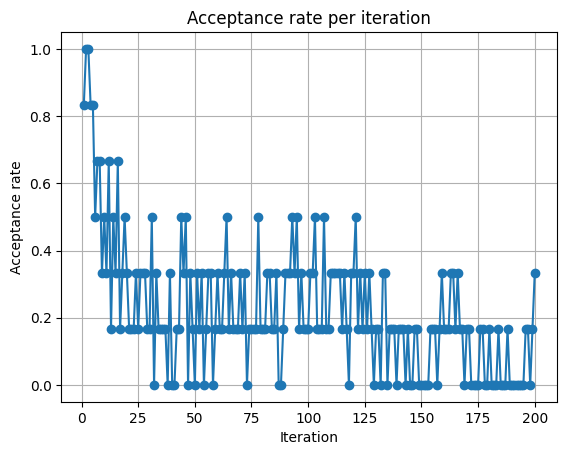

In [7]:
# Acceptance rate per iteration
accept_hist = outs[4]

acc_rate = np.asarray(jnp.mean(accept_hist,axis=1),dtype=float)
iters = np.arange(1,len(acc_rate) + 1)

plt.figure()
plt.plot(iters,acc_rate,marker="o")
plt.xlabel("Iteration")
plt.ylabel("Acceptance rate")
plt.title("Acceptance rate per iteration")
plt.grid(True)
plt.show()

## Initialization and random generation of agents

In [8]:
# MAIN LOOP PARAMETERS
benchmark_family = "2d"
objective_id = b2d.SIX_HUMP_ZERO_MIN   # or b2d.SIX_HUMP_WIDE / LOW_CONTRAST / HIGH_CONTRAST
dim = None
# Getting bounds from objective
bounds = get_bounds(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)
objective_fn = make_objective_fn(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)
lo, hi = bounds[:, 0], bounds[:, 1] 

# Agent params
agent_hyper = {"bounds": bounds}
agent_params = abx_struct.Params(content=agent_hyper)

# PRNG key for JAX 
key = random.PRNGKey(24)

# Creating ids and active flags for agents
ids = jnp.arange(num_agents, dtype=jnp.int32)
active_states = jnp.ones(num_agents, dtype=bool)

# Split key into one subkey per agent
key, key_agents = random.split(key)
subkeys = jax.vmap(lambda i: random.fold_in(key_agents, i))(ids)  

# Vectorized creation of agents:
# Creating agents
agents = jax.vmap(Forager.create_agent,in_axes=(None, None, 0, 0, 0),)(agent_type, agent_params, ids, active_states, subkeys)
# Extract positions and fitnesses from the batched agents
pos = agents.state.content["pos"]  # shape (num_agents, D)
fit = agents.state.content["fit"]  # shape (num_agents,)

print("Positions shape:", pos.shape)
print("Fitness shape:", fit.shape)
print("All ten positions:\n", pos)
print("All ten fitnesses (may be inf before eval):\n", fit)

print("Min pos per dim:", pos.min(axis=0))
print("Max pos per dim:", pos.max(axis=0))


# Evaluating positions fitness, then write back into agent state
fit_eval = evaluate_positions(pos, objective_fn)  # (N,)
agents = initialize_fitness_in_agents(agents, fit_eval, set_best=True, set_evals_to=1)

print("Fitness after explicit evaluation:\n", agents.state.content["fit"])

Positions shape: (6, 2)
Fitness shape: (6,)
All ten positions:
 [[ 0.15403605 -0.14770293]
 [-0.6128473  -0.40749288]
 [-0.80609035 -0.22119117]
 [ 1.1844368   0.22172642]
 [ 0.86923504 -0.9664173 ]
 [ 1.0212135   0.98994875]]
All ten fitnesses (may be inf before eval):
 [inf inf inf inf inf inf]
Min pos per dim: [-0.80609035 -0.9664173 ]
Max pos per dim: [1.1844368  0.98994875]
Fitness after explicit evaluation:
 [1.0172467 1.9512067 2.8277235 3.5061588 1.9120784 4.229811 ]


## Visualization of randomly generated agents

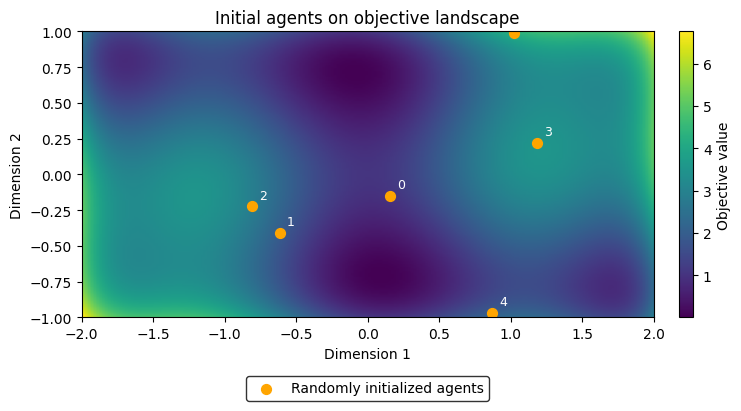

In [ ]:
# Getting bounds from objective
bounds = get_bounds(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)
objective_fn = make_objective_fn(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)
lo, hi = bounds[:, 0], bounds[:, 1]

# Making grid
res = 200
x = jnp.linspace(bounds[0, 0], bounds[0, 1], res)
y = jnp.linspace(bounds[1, 0], bounds[1, 1], res)
xg, yg = jnp.meshgrid(x, y)

# Evaluating objective on the grid to produce a heat map
grid_points = jnp.stack([xg.reshape(-1), yg.reshape(-1)], axis=1)
Z = evaluate_positions(grid_points, objective_fn).reshape(res, res)

# Getting agent positions for plotting
x_agents = np.array(pos[:, 0])
y_agents = np.array(pos[:, 1])
ids_np   = np.array(ids)

# Make figure: wider, because x-range is twice y-range
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

# Plotting heatmap
heat_map = ax.imshow(Z,extent=[float(bounds[0, 0]), float(bounds[0, 1]),float(bounds[1, 0]), float(bounds[1, 1])],origin="lower",aspect="equal")

# Colorbar with height matched to axes
cbar = fig.colorbar(heat_map, ax=ax, pad=0.02)
cbar.set_label("Objective value")

# Plotting agents
# Plotting agents
ax.scatter(x_agents, y_agents, s=50, color="orange", label="Randomly initialized agents")

for i in range(len(x_agents)):
    ax.text(float(x_agents[i]) + 0.05,float(y_agents[i]) + 0.05,str(int(ids_np[i])),fontsize=9,color="white")

ax.set_xlim(bounds[0, 0], bounds[0, 1])
ax.set_ylim(bounds[1, 0], bounds[1, 1])
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Initial agents on objective landscape")

# Legend outside, below the plot
ax.legend(loc="upper center",bbox_to_anchor=(0.5, -0.18),ncol=1,frameon=True,facecolor="white",edgecolor="black",fontsize=10)

# Save tightly cropped SVG
from pathlib import Path

figures_dir = Path("Trash_fig")
figures_dir.mkdir(exist_ok=True)
output_path = figures_dir / "random_initialization.svg"
fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.02)

plt.show()

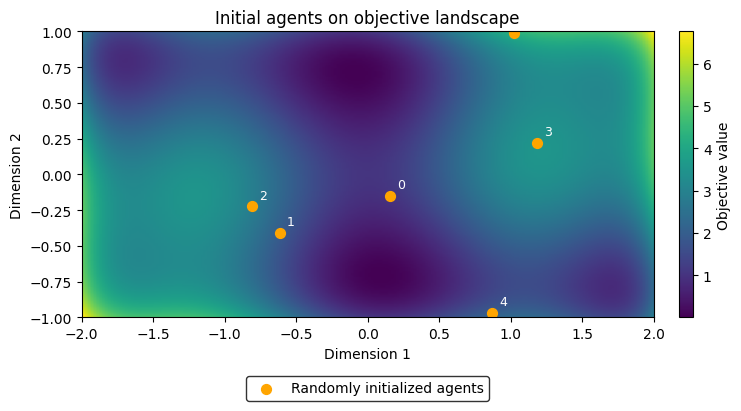

In [ ]:
# Getting bounds from objective
bounds = get_bounds(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)
objective_fn = make_objective_fn(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)
lo, hi = bounds[:, 0], bounds[:, 1]

# Making grid
res = 200
x = jnp.linspace(bounds[0, 0], bounds[0, 1], res)
y = jnp.linspace(bounds[1, 0], bounds[1, 1], res)
xg, yg = jnp.meshgrid(x, y)

# Evaluating objective on the grid to produce a heat map
grid_points = jnp.stack([xg.reshape(-1), yg.reshape(-1)], axis=1)
Z = evaluate_positions(grid_points, objective_fn).reshape(res, res)

# Getting agent positions for plotting
x_agents = np.array(pos[:, 0])
y_agents = np.array(pos[:, 1])
ids_np   = np.array(ids)

# Make figure: wider, because x-range is twice y-range
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

# Plotting heatmap
heat_map = ax.imshow(
    Z,
    extent=[
        float(bounds[0, 0]), float(bounds[0, 1]),
        float(bounds[1, 0]), float(bounds[1, 1])
    ],
    origin="lower",
    aspect="equal"
)

# Colorbar with height matched to axes
cbar = fig.colorbar(heat_map, ax=ax, pad=0.02)
cbar.set_label("Objective value")

# Plotting agents
# Plotting agents
ax.scatter(x_agents, y_agents, s=50, color="orange", label="Randomly initialized agents")

for i in range(len(x_agents)):
    ax.text(
        float(x_agents[i]) + 0.05,
        float(y_agents[i]) + 0.05,
        str(int(ids_np[i])),
        fontsize=9,
        color="white"
    )

ax.set_xlim(bounds[0, 0], bounds[0, 1])
ax.set_ylim(bounds[1, 0], bounds[1, 1])
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Initial agents on objective landscape")

# Legend outside, below the plot
ax.legend(loc="upper center",bbox_to_anchor=(0.5, -0.18),ncol=1,frameon=True,facecolor="white",edgecolor="black",fontsize=10)

figures_dir = Path("Trash_fig")
figures_dir.mkdir(exist_ok=True)

output_path = figures_dir / "bad_initialization.svg"
fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.02)
plt.show()

## Generating quassi opposite agents

In [12]:
# Bounds and center
center = (lo + hi) / 2.0  

# Finding oposite position for each agent
pos_op = lo + hi - pos  

# Generating quasi opposite position - random uniform sampling between center and pos_op

key, key_q = random.split(key)
u = random.uniform(key_q, shape=pos.shape)  
q_low  = jnp.minimum(center, pos_op)       
q_high = jnp.maximum(center, pos_op)
pos_qop = q_low + u * (q_high - q_low)

num_agents = pos.shape[0]   
agent_type = jnp.int16(0)
                                
ids_qop  = ids + num_agents
active_qop = jnp.ones(num_agents, dtype=bool)

# Random keys for quasi agents
key, key_q_agents = random.split(key)
subkeys_q = jax.vmap(lambda i: random.fold_in(key_q_agents, i))(ids_qop)

# Creating quasi agents
agents_qop = jax.vmap(Forager.create_agent_at_pos, in_axes=(None, None, 0, 0, 0, 0),)(agent_type, agent_params, ids_qop, active_qop, subkeys_q, pos_qop)

# Evaluation step for quasi agents
fit_qop_eval = evaluate_positions(pos_qop, objective_fn)  # (N,)
agents_qop = initialize_fitness_in_agents(agents_qop, fit_qop_eval, set_best=True, set_evals_to=1)

# Printing
print("Original agents positions:\n", pos)
print("Quasi agents positions:\n", pos_qop)
print("QOP fitness shape:", agents_qop.state.content["fit"].shape)
print("All QOP fitnesses:\n", agents_qop.state.content["fit"])

Original agents positions:
 [[ 0.15403605 -0.14770293]
 [-0.6128473  -0.40749288]
 [-0.80609035 -0.22119117]
 [ 1.1844368   0.22172642]
 [ 0.86923504 -0.9664173 ]
 [ 1.0212135   0.98994875]]
Quasi agents positions:
 [[-0.06182619  0.14147381]
 [ 0.56347215  0.21312062]
 [ 0.769825    0.18052672]
 [-1.1549426  -0.15519606]
 [-0.15416354  0.9626137 ]
 [-0.61173064 -0.6403953 ]]
QOP fitness shape: (6,)
All QOP fitnesses:
 [0.95968395 2.047264   2.7468498  3.507071   0.70514846 1.6759505 ]


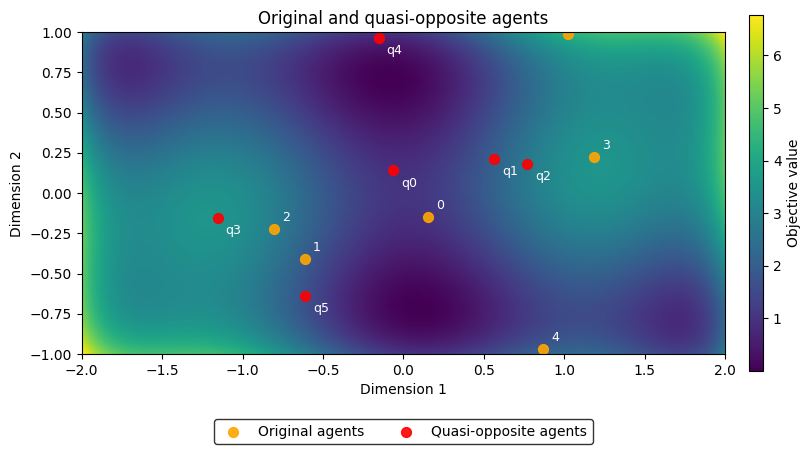

In [13]:
# Getting bounds from objective
bounds = get_bounds(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)
objective_fn = make_objective_fn(benchmark_family=benchmark_family, objective_id=objective_id, dim=dim)
lo, hi = bounds[:, 0], bounds[:, 1]

# Making grid
res = 200
x = jnp.linspace(bounds[0, 0], bounds[0, 1], res)
y = jnp.linspace(bounds[1, 0], bounds[1, 1], res)
xg, yg = jnp.meshgrid(x, y)

# Evaluating objective on the grid to produce a heat map
grid_points = jnp.stack([xg.reshape(-1), yg.reshape(-1)], axis=1)
Z = evaluate_positions(grid_points, objective_fn).reshape(res, res)

# Getting agent positions
x_orig = np.array(pos[:, 0])
y_orig = np.array(pos[:, 1])

x_q = np.array(pos_qop[:, 0])
y_q = np.array(pos_qop[:, 1])

ids_np = np.array(ids)

# Plotting
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

# Background heatmap
heat_map = ax.imshow(
    np.array(Z),
    extent=[
        float(bounds[0, 0]), float(bounds[0, 1]),
        float(bounds[1, 0]), float(bounds[1, 1])
    ],
    origin="lower",
    aspect="equal"
)

# Shorter and slightly thinner colorbar
cbar = fig.colorbar(heat_map,ax=ax,pad=0.02,shrink=0.82,fraction=0.045,aspect=25)
cbar.set_label("Objective value")

# Original agents in orange
ax.scatter(x_orig, y_orig, s=50, color="orange", label="Original agents", alpha=0.9)

# Quasi-opposite agents in red
ax.scatter(x_q, y_q, s=50, color="red", label="Quasi-opposite agents", alpha=0.9)

# Label original agents with their id
for i in range(len(x_orig)):
    ax.text(
        float(x_orig[i]) + 0.05,
        float(y_orig[i]) + 0.05,
        str(int(ids_np[i])),
        fontsize=9,
        color="white"
    )

# Label quasi agents with "q{id}"
for i in range(len(x_q)):
    ax.text(
        float(x_q[i]) + 0.05,
        float(y_q[i]) - 0.10,
        f"q{int(ids_np[i])}",
        fontsize=9,
        color="white"
    )

ax.set_xlim(float(bounds[0, 0]), float(bounds[0, 1]))
ax.set_ylim(float(bounds[1, 0]), float(bounds[1, 1]))
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Original and quasi-opposite agents")
ax.grid(False)
ax.set_aspect("equal", adjustable="box")

# Legend outside, below the plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=10
)

#Saving
figures_dir = Path("Figures")
figures_dir.mkdir(exist_ok=True)
output_path = figures_dir / "original_vs_quasi_opposite_agents.svg"
fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.02)
plt.show()

# QOBL Principle Visualization

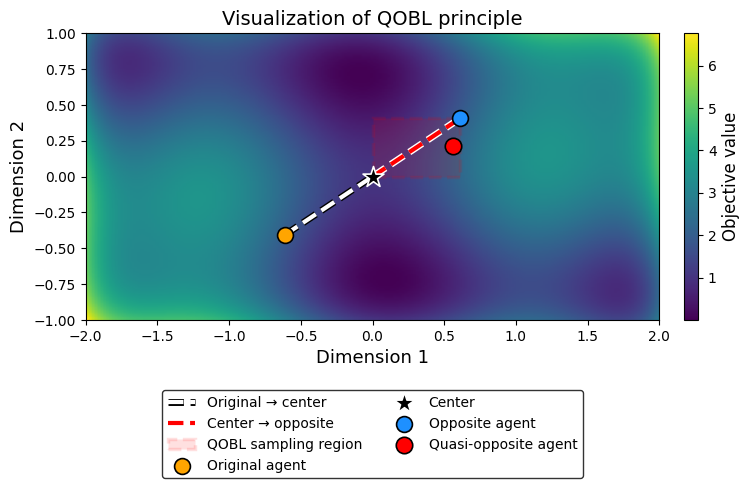

In [ ]:
# Agent to visualize
selected_agent_idx = 1

# Converting to numpy
x_orig = np.array(pos[selected_agent_idx])
x_op = np.array(pos_op[selected_agent_idx])
x_qop = np.array(pos_qop[selected_agent_idx])
c = np.array(center)

# Rectangle from center to opposite
rect_x = min(c[0],x_op[0])
rect_y = min(c[1],x_op[1])
rect_w = abs(x_op[0] - c[0])
rect_h = abs(x_op[1] - c[1])

# Plotting
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

# Heatmap
heat_map = ax.imshow(
    np.array(Z),
    extent=[float(bounds[0,0]),float(bounds[0,1]),float(bounds[1,0]),float(bounds[1,1])],
    origin="lower",
    aspect="equal"
)

# Colorbar
cbar = fig.colorbar(heat_map,ax=ax,pad=0.02)
cbar.set_label("Objective value",fontsize=12)

# Original -> center
line_white, = ax.plot(
    [x_orig[0],c[0]],
    [x_orig[1],c[1]],
    linestyle="--",
    linewidth=3,
    color="white",
    zorder=4,
    label="Original → center"
)
line_white.set_path_effects([pe.Stroke(linewidth=5,foreground="black"),pe.Normal()])

# Center -> opposite
line_red, = ax.plot([c[0],x_op[0]],[c[1],x_op[1]],linestyle="--",linewidth=3,color="red",zorder=4,label="Center → opposite")
line_red.set_path_effects([pe.Stroke(linewidth=5,foreground="white"),pe.Normal()])

# QOBL sampling region
rect = patches.Rectangle(
    (rect_x, rect_y),
    rect_w,
    rect_h,
    linewidth=2.5,
    edgecolor="red",
    facecolor="red",
    linestyle="--",
    alpha=0.12,
    zorder=2,
    label="QOBL sampling region"
)
ax.add_patch(rect)

# Points
ax.scatter(x_orig[0],x_orig[1],s=130,color="orange",edgecolor="black",linewidth=1.2,zorder=6,label="Original agent")
ax.scatter(c[0],c[1],s=250,color="black",marker="*",edgecolor="white",linewidth=1.2,zorder=7,label="Center")
ax.scatter(x_op[0],x_op[1],s=130,color="dodgerblue",edgecolor="black",linewidth=1.2,zorder=6,label="Opposite agent")
ax.scatter(x_qop[0],x_qop[1],s=140,color="red",edgecolor="black",linewidth=1.2,zorder=7,label="Quasi-opposite agent")

# Formatting
ax.set_xlim(float(bounds[0,0]),float(bounds[0,1]))
ax.set_ylim(float(bounds[1,0]),float(bounds[1,1]))

ax.set_xlabel("Dimension 1",fontsize=13)
ax.set_ylabel("Dimension 2",fontsize=13)
ax.set_title("Visualization of QOBL principle",fontsize=14)

ax.set_aspect("equal",adjustable="box")
ax.grid(False)

# Legend
ax.legend(loc="upper center",bbox_to_anchor=(0.5,-0.22),ncol=2,frameon=True,facecolor="white",edgecolor="black",fontsize=10)

# Saving SVG
figures_dir = Path("Trash_fig")
figures_dir.mkdir(exist_ok=True)

output_path = figures_dir / "qobl_principle.svg"
fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.02)
plt.show()

## Extracting best N/2 agents from the set of randomly generated agents and quasi generated agents

In [16]:
# Combining original and quasi-opposite agents into a single population
agents_all = jax.tree_util.tree_map(lambda a, b: jnp.concatenate([a, b], axis=0), agents, agents_qop)

print("Combined agents positions shape:", agents_all.state.content["pos"].shape)
print("Combined agents fitness shape:", agents_all.state.content["fit"].shape)

# 0 = original, 1 = quasi
origin_flags_all = jnp.concatenate([jnp.zeros(num_agents, dtype=jnp.int32), jnp.ones(num_agents, dtype=jnp.int32)])

# Sort all 2N agents by fitness (ascending)
agents_sorted, sorted_idx = Forager.sort_agents_by_fitness(agents_all)
origin_sorted = origin_flags_all[sorted_idx]

# Keep only the best half
M = agents_sorted.state.content["fit"].shape[0]   # should be 2N
M_keep = M // 2                                   # N

agents_init = jax.tree_util.tree_map(lambda x: x[:M_keep], agents_sorted)
origin_init = origin_sorted[:M_keep]

# For checks
pos_init = agents_init.state.content["pos"]
fit_init = agents_init.state.content["fit"]
ids_init = agents_init.id

print("Initial population size:", pos_init.shape[0])  # should be N
print("Ids:", ids_init)
print("Origin flags (0=orig, 1=quasi):", origin_init)
print("Fitness:\n", fit_init)

Combined agents positions shape: (12, 2)
Combined agents fitness shape: (12,)
Initial population size: 6
Ids: [10  6  0 11  4  1]
Origin flags (0=orig, 1=quasi): [1 1 0 1 0 0]
Fitness:
 [0.70514846 0.95968395 1.0172467  1.6759505  1.9120784  1.9512067 ]


## Plotting N best agents which will be used in algorithm

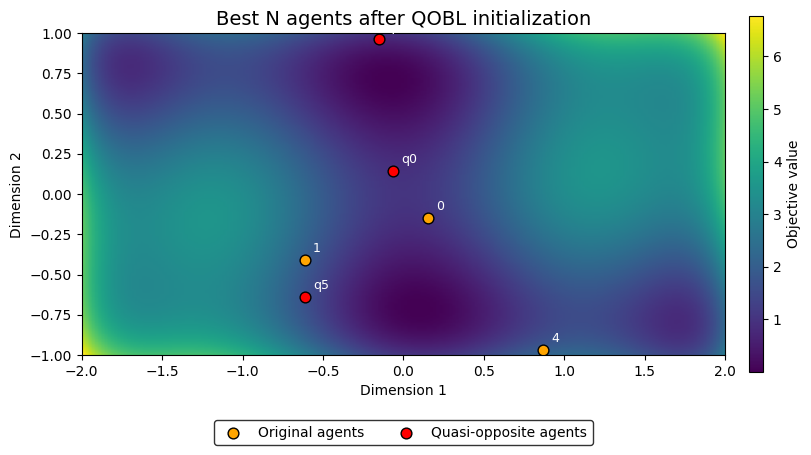

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from pathlib import Path

# Positions & ids for plotting
pos_init_np    = np.array(pos_init)
x_agents       = pos_init_np[:, 0]
y_agents       = pos_init_np[:, 1]
ids_init_np    = np.array(ids_init)
origin_init_np = np.array(origin_init)

# Masks for original vs quasi
orig_mask  = origin_init_np == 0
quasi_mask = origin_init_np != 0
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

# Heatmap
heat_map = ax.imshow(
    np.array(Z),
    extent=[
        float(bounds[0, 0]), float(bounds[0, 1]),
        float(bounds[1, 0]), float(bounds[1, 1])
    ],
    origin="lower",
    aspect="equal"
)

# Shorter and slightly thinner colorbar
cbar = fig.colorbar(heat_map,ax=ax,pad=0.02,shrink=0.82,fraction=0.045,aspect=25)
cbar.set_label("Objective value")

# Plot original and quasi agents separately so legend works cleanly
ax.scatter(x_agents[orig_mask],y_agents[orig_mask],s=60,c="orange",edgecolors="black",label="Original agents")

ax.scatter(x_agents[quasi_mask],y_agents[quasi_mask],s=60,c="red",edgecolors="black",label="Quasi-opposite agents")

# Labels
for i in range(len(x_agents)):
    if origin_init_np[i] == 0:
        label = str(int(ids_init_np[i]))   # original
    else:
        base_id = int(ids_init_np[i] % num_agents)
        label = f"q{base_id}"              # quasi

    ax.text(float(x_agents[i]) + 0.05,float(y_agents[i]) + 0.05,label,fontsize=9,color="white")

# Axes formatting
ax.set_xlim(float(bounds[0, 0]), float(bounds[0, 1]))
ax.set_ylim(float(bounds[1, 0]), float(bounds[1, 1]))
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Best N agents after QOBL initialization", fontsize=14)
ax.set_aspect("equal", adjustable="box")
ax.grid(False)

# Legend outside, below the plot
ax.legend(loc="upper center",bbox_to_anchor=(0.5, -0.18),ncol=2,frameon=True,facecolor="white",edgecolor="black",fontsize=10)

figures_dir = Path("Figures")
figures_dir.mkdir(exist_ok=True)

output_path = figures_dir / "best_n_agents_original_vs_quasi.svg"
fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.02)
plt.show()

# Acceptance rule over iterations

FINAL (debug loop) sorted IDs: [11  6  4  0  1 10]
FINAL (debug loop) sorted fit: [0. 0. 0. 0. 0. 0.]


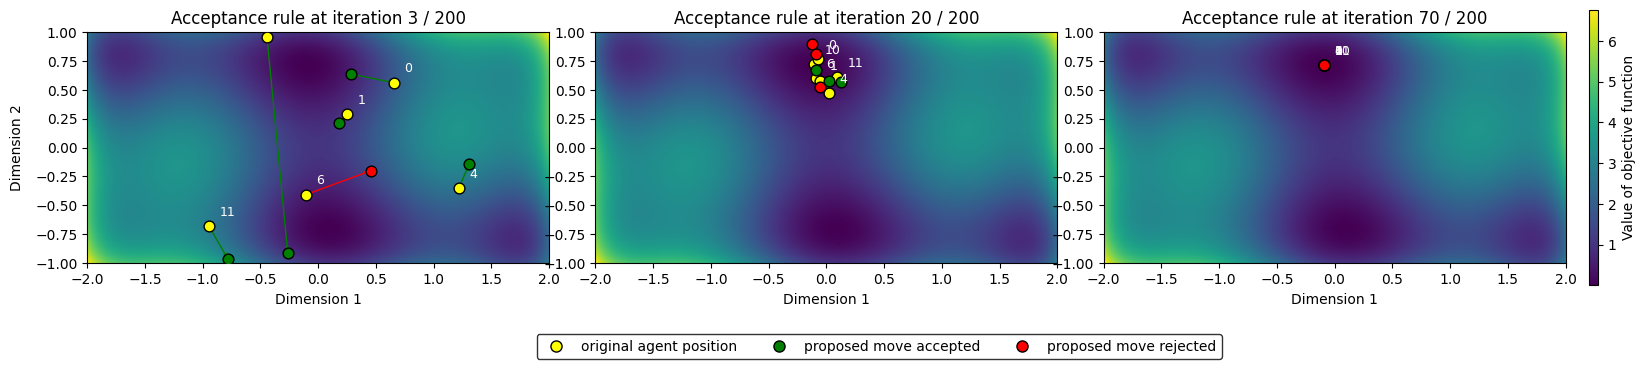

In [21]:
agents_dbg = agents_init
key_dbg = random.PRNGKey(35)
T = 200

# Iterations to visualize
iterations_to_plot = [3,20,70]

bounds = jnp.stack([lo,hi],axis=1)
xmin, xmax = float(bounds[0,0]), float(bounds[0,1])
ymin, ymax = float(bounds[1,0]), float(bounds[1,1])

# Heatmap
res = 200
x = jnp.linspace(bounds[0,0],bounds[0,1],res)
y = jnp.linspace(bounds[1,0],bounds[1,1],res)
xg, yg = jnp.meshgrid(x,y)

grid_points = jnp.stack([xg.reshape(-1),yg.reshape(-1)],axis=1)
Z = evaluate_positions(grid_points,objective_fn).reshape(res,res)
Z_np = np.array(Z)

# Snapshots
snapshots = {}

# Figures folder
figures_dir = Path("Figures")
figures_dir.mkdir(exist_ok=True)

for t0 in range(T):
    t_iter = jnp.int32(t0 + 1)

    # Sort for ranking
    agents_sorted, _ = Forager.sort_agents_by_fitness(agents_dbg)

    pos_parent = agents_sorted.state.content["pos"]
    fit_parent = agents_sorted.state.content["fit"]
    ids_parent = agents_sorted.id

    k_t = cosine_k(t_iter,T)

    key_dbg, pos_offspring, recruitment_step, social_step = generate_agent_positions(key_dbg,pos_parent,lo,hi,k_t)
    fit_offspring = evaluate_positions(pos_offspring,objective_fn)

    key_dbg, accept = acceptance_rule_mask(key_dbg,fit_parent=fit_parent,fit_offspring=fit_offspring,t=t_iter)

    accept_np = np.array(accept)
    reject_np = ~accept_np

    P = np.array(pos_parent)
    O = np.array(pos_offspring)
    ids_np = np.array(ids_parent)

    # Save selected iterations
    if int(t_iter) in iterations_to_plot:
        snapshots[int(t_iter)] = {
            "P": P.copy(),
            "O": O.copy(),
            "ids": ids_np.copy(),
            "accept": accept_np.copy(),
            "reject": reject_np.copy(),
            "k_t": float(k_t),
            "accept_rate": float(jnp.mean(accept)),
        }

    # Update population
    agents_dbg = apply_acceptance_update(agents_sorted,pos_offspring=pos_offspring,fit_offspring=fit_offspring,accept=accept)

# Final output
fit_final = agents_dbg.state.content["fit"]
ids_final = agents_dbg.id

print("FINAL (debug loop) sorted IDs:", np.array(ids_final))
print("FINAL (debug loop) sorted fit:", np.array(fit_final))


# Acceptance rule figure
fig, axes = plt.subplots(1,3,figsize=(18,4.8),constrained_layout=False)

fig.subplots_adjust(left=0.06,right=0.92,bottom=0.18,top=0.88,wspace=0.10)
im = None

for panel_idx, (ax, iteration) in enumerate(zip(axes,iterations_to_plot)):
    snap = snapshots[iteration]

    P = snap["P"]
    O = snap["O"]
    ids_np = snap["ids"]
    accept_np = snap["accept"]
    reject_np = snap["reject"]

    # Heatmap
    im = ax.imshow(Z_np,extent=[xmin,xmax,ymin,ymax],origin="lower",aspect="equal")

    # Parent positions
    ax.scatter(P[:,0],P[:,1],s=60,color="yellow",edgecolors="black",zorder=3)

    # Accepted offspring
    if np.any(accept_np):
        ax.scatter(O[accept_np,0],O[accept_np,1],s=60,color="green",edgecolors="black",zorder=4)

    # Rejected offspring
    if np.any(reject_np):
        ax.scatter(O[reject_np,0],O[reject_np,1],s=60,color="red",edgecolors="black",zorder=4)

    # Arrows
    d = O - P

    if np.any(accept_np):
        ax.quiver(P[accept_np,0],P[accept_np,1],d[accept_np,0],d[accept_np,1],angles="xy",scale_units="xy",scale=1,color="green",width=0.003,zorder=2)

    if np.any(reject_np):
        ax.quiver(P[reject_np,0],P[reject_np,1],d[reject_np,0],d[reject_np,1],angles="xy",scale_units="xy",scale=1,color="red",width=0.003,zorder=2)

    # ID labels
    for i in range(P.shape[0]):
        ax.text(float(P[i,0]) + 0.09,float(P[i,1]) + 0.09,str(int(ids_np[i])),fontsize=9,color="white",zorder=5,clip_on=True)

    # Formatting
    ax.set_xlim(xmin,xmax)
    ax.set_ylim(ymin,ymax)
    ax.set_xlabel("Dimension 1")

    if panel_idx == 0:
        ax.set_ylabel("Dimension 2",labelpad=8)
    else:
        ax.set_ylabel("")

    ax.set_aspect("equal",adjustable="box")
    ax.grid(False)
    ax.set_title(f"Acceptance rule at iteration {iteration} / {T}",fontsize=12)

# Shared colorbar
cbar = fig.colorbar(im,ax=axes,pad=0.015,shrink=0.82,fraction=0.03,aspect=30)
cbar.set_label("Value of objective function")

# Shared legend
legend_handles = [
    Line2D([0],[0],marker="o",color="w",markerfacecolor="yellow",markeredgecolor="black",markersize=8,label="original agent position"),
    Line2D([0],[0],marker="o",color="w",markerfacecolor="green",markeredgecolor="black",markersize=8,label="proposed move accepted"),
    Line2D([0],[0],marker="o",color="w",markerfacecolor="red",markeredgecolor="black",markersize=8,label="proposed move rejected"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5,0.075),
    ncol=3,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=10
)

# Saving SVG
output_path = figures_dir / "acceptance_rule_iterations_3_20_70.svg"

fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.01)

plt.show()

# Acceptance rule showcase

FINAL (debug loop) sorted IDs: [ 0 10  4  1 11  6]
FINAL (debug loop) sorted fit: [0.00497818 0.00820851 0.00497818 0.5317181  0.00497806 1.0407158 ]


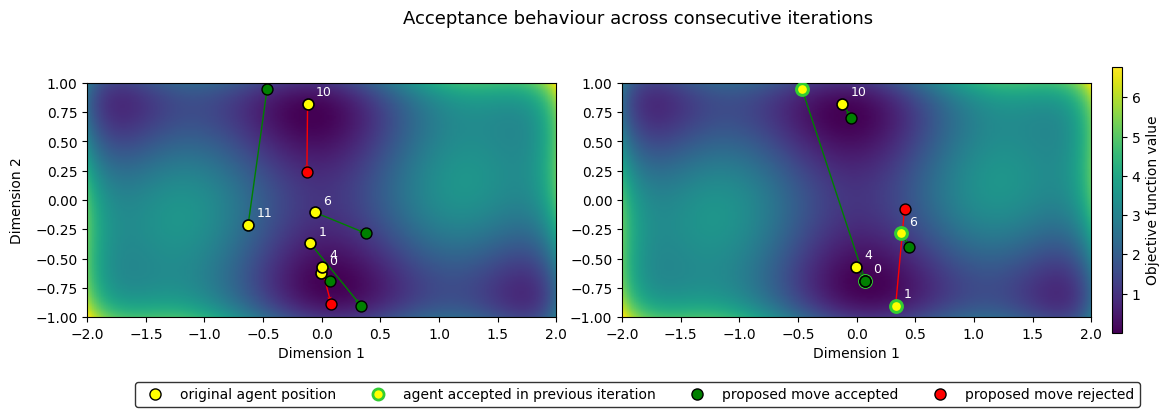

In [22]:
agents_dbg = agents_init
key_dbg = random.PRNGKey(21)
T = 6

# Iterations to visualize
iterations_to_plot = [5,6]

bounds = jnp.stack([lo,hi],axis=1)
xmin, xmax = float(bounds[0,0]), float(bounds[0,1])
ymin, ymax = float(bounds[1,0]), float(bounds[1,1])

# Heatmap
res = 200
x = jnp.linspace(bounds[0,0],bounds[0,1],res)
y = jnp.linspace(bounds[1,0],bounds[1,1],res)
xg, yg = jnp.meshgrid(x,y)

grid_points = jnp.stack([xg.reshape(-1),yg.reshape(-1)],axis=1)
Z = evaluate_positions(grid_points,objective_fn).reshape(res,res)
Z_np = np.array(Z)

# Figures folder
figures_dir = Path("Figures")
figures_dir.mkdir(exist_ok=True)

# Snapshots
snapshots = {}
accepted_ids_previous_iter = np.array([],dtype=int)

for t0 in range(T):
    t_iter = jnp.int32(t0 + 1)

    # Sort for ranking
    agents_sorted, _ = Forager.sort_agents_by_fitness(agents_dbg)

    pos_parent = agents_sorted.state.content["pos"]
    fit_parent = agents_sorted.state.content["fit"]
    ids_parent = agents_sorted.id

    k_t = cosine_k(t_iter,T)

    key_dbg, pos_offspring, recruitment_step, social_step = generate_agent_positions(key_dbg,pos_parent,lo,hi,k_t)
    fit_offspring = evaluate_positions(pos_offspring,objective_fn)
    key_dbg, accept = acceptance_rule_mask(key_dbg,fit_parent=fit_parent,fit_offspring=fit_offspring,t=t_iter)

    accept_np = np.array(accept)
    reject_np = ~accept_np

    P = np.array(pos_parent)
    O = np.array(pos_offspring)
    ids_np = np.array(ids_parent)

    # Agents accepted in the previous iteration
    moved_in_previous_iteration_mask = np.isin(ids_np,accepted_ids_previous_iter)

    # Save selected iterations
    if int(t_iter) in iterations_to_plot:
        snapshots[int(t_iter)] = {
            "P": P.copy(),
            "O": O.copy(),
            "ids": ids_np.copy(),
            "accept": accept_np.copy(),
            "reject": reject_np.copy(),
            "moved_prev_mask": moved_in_previous_iteration_mask.copy(),
        }

    accepted_ids_previous_iter = ids_np[accept_np].copy()

    # Update population
    agents_dbg = apply_acceptance_update(agents_sorted,pos_offspring=pos_offspring,fit_offspring=fit_offspring,accept=accept)

# Final output
fit_final = agents_dbg.state.content["fit"]
ids_final = agents_dbg.id

print("FINAL (debug loop) sorted IDs:",np.array(ids_final))
print("FINAL (debug loop) sorted fit:",np.array(fit_final))


# Consecutive acceptance iterations
fig, axes = plt.subplots(1,2,figsize=(12.8,4.65),constrained_layout=False)

fig.subplots_adjust(left=0.07,right=0.90,bottom=0.18,top=0.86,wspace=0.14)

im = None

for panel_idx, (ax, iteration) in enumerate(zip(axes,iterations_to_plot)):
    snap = snapshots[iteration]

    P = snap["P"]
    O = snap["O"]
    ids_np = snap["ids"]
    accept_np = snap["accept"]
    reject_np = snap["reject"]
    moved_prev_mask = snap["moved_prev_mask"]

    # Heatmap
    im = ax.imshow(Z_np,extent=[xmin,xmax,ymin,ymax],origin="lower",aspect="equal")

    # Parent positions
    if panel_idx == 0:
        ax.scatter(P[:,0],P[:,1],s=62,color="yellow",edgecolors="black",linewidths=1.2,zorder=3)

    else:
        moved_mask = moved_prev_mask
        not_moved_mask = ~moved_mask

        if np.any(not_moved_mask):
            ax.scatter(
                P[not_moved_mask,0],P[not_moved_mask,1],
                s=62,color="yellow",edgecolors="black",linewidths=1.2,zorder=3
            )

        if np.any(moved_mask):
            ax.scatter(
                P[moved_mask,0],P[moved_mask,1],
                s=72,color="yellow",edgecolors="limegreen",linewidths=2.2,zorder=4
            )

    # Accepted and rejected offspring
    if np.any(accept_np):
        ax.scatter(
            O[accept_np,0],O[accept_np,1],
            s=62,color="green",edgecolors="black",linewidths=1.0,zorder=5
        )

    if np.any(reject_np):
        ax.scatter(
            O[reject_np,0],O[reject_np,1],
            s=62,color="red",edgecolors="black",linewidths=1.0,zorder=5
        )

    # Movement arrows
    d = O - P

    if np.any(accept_np):
        ax.quiver(
            P[accept_np,0],P[accept_np,1],
            d[accept_np,0],d[accept_np,1],
            angles="xy",scale_units="xy",scale=1,color="green",width=0.003,zorder=2
        )

    if np.any(reject_np):
        ax.quiver(
            P[reject_np,0],P[reject_np,1],
            d[reject_np,0],d[reject_np,1],
            angles="xy",scale_units="xy",scale=1,color="red",width=0.003,zorder=2
        )

    # Agent labels
    for i in range(P.shape[0]):
        ax.text(
            float(P[i,0]) + 0.07,
            float(P[i,1]) + 0.07,
            str(int(ids_np[i])),
            fontsize=9,
            color="white",
            zorder=6,
            clip_on=True
        )

    # Formatting
    ax.set_xlim(xmin,xmax)
    ax.set_ylim(ymin,ymax)
    ax.set_xlabel("Dimension 1")

    if panel_idx == 0:
        ax.set_ylabel("Dimension 2",labelpad=8)
    else:
        ax.set_ylabel("")

    ax.set_aspect("equal",adjustable="box")
    ax.grid(False)

# Title
fig.suptitle("Acceptance behaviour across consecutive iterations",fontsize=13,y=0.93)

# Colorbar
cbar = fig.colorbar(im,ax=axes,pad=0.02,shrink=0.84,fraction=0.035,aspect=28)
cbar.set_label("Objective function value")

# Legend
legend_handles = [
    Line2D([0],[0],marker="o",color="w",markerfacecolor="yellow",markeredgecolor="black",markersize=8,label="original agent position"),
    Line2D([0],[0],marker="o",color="w",markerfacecolor="yellow",markeredgecolor="limegreen",markeredgewidth=2.0,markersize=8,label="agent accepted in previous iteration"),
    Line2D([0],[0],marker="o",color="w",markerfacecolor="green",markeredgecolor="black",markersize=8,label="proposed move accepted"),
    Line2D([0],[0],marker="o",color="w",markerfacecolor="red",markeredgecolor="black",markersize=8,label="proposed move rejected"),
]

fig.legend(handles=legend_handles,loc="lower center",bbox_to_anchor=(0.5,0.06),ncol=4,frameon=True,facecolor="white",edgecolor="black",fontsize=10)
# Saving SVG
output_path = figures_dir / "acceptance_rule_consecutive_iterations.svg"
fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.01)
plt.show()

# Representation of social behaviour

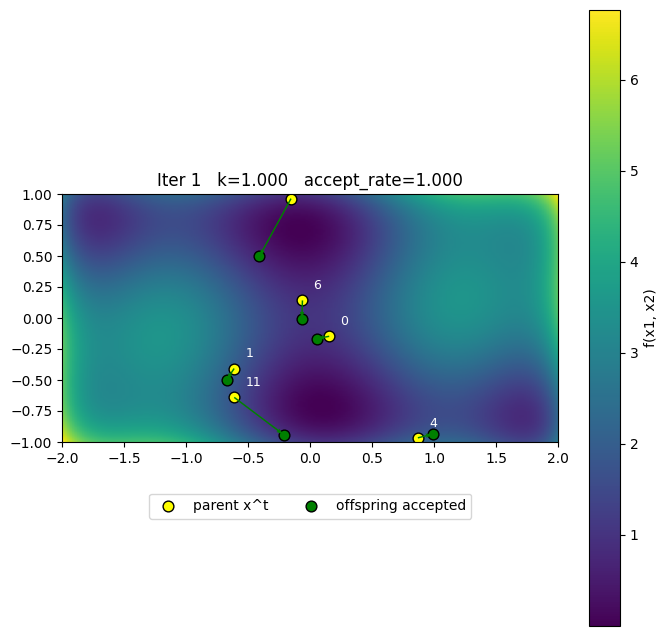

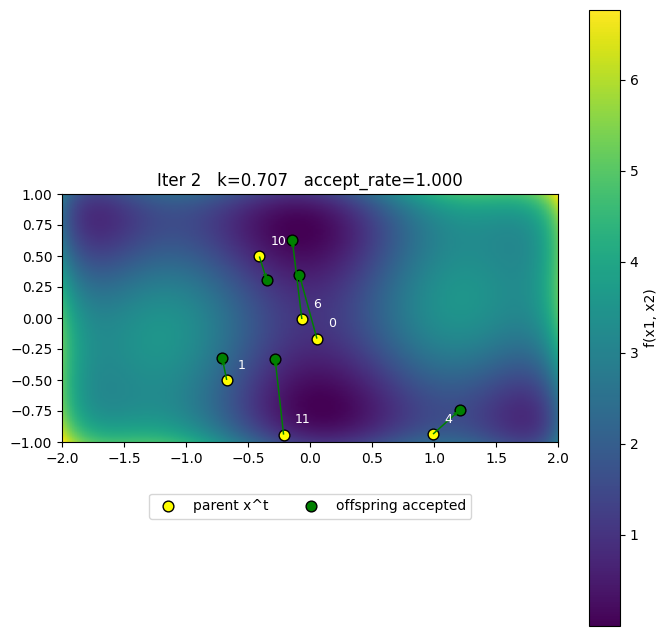

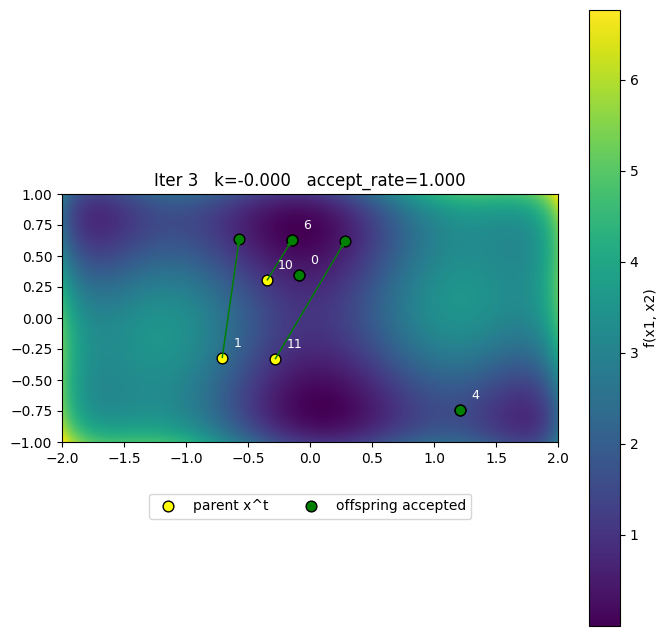

FINAL (debug loop) sorted IDs: [ 6  0 11 10  4  1]
FINAL (debug loop) sorted fit: [0.06440878 0.6082408  0.56646836 0.06440878 1.5466864  0.79123175]


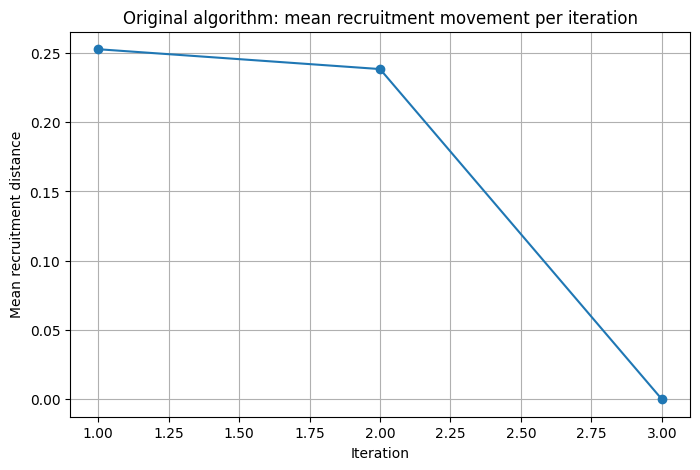

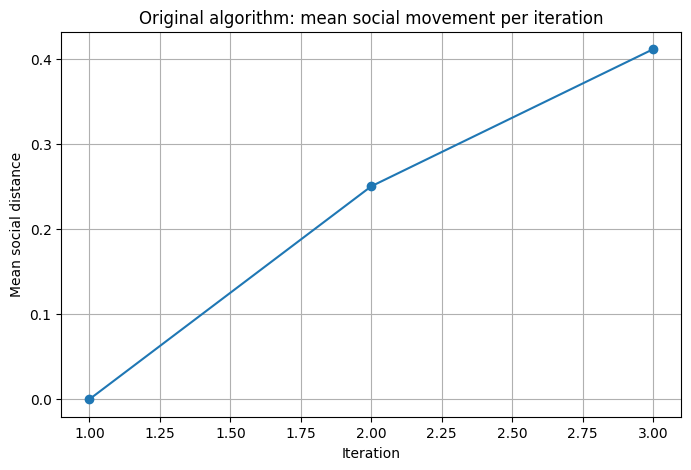

In [23]:
agents_dbg = agents_init
key_dbg = random.PRNGKey(319)
T = 3

bounds = jnp.stack([lo, hi], axis=1)
xmin, xmax = float(bounds[0, 0]), float(bounds[0, 1])
ymin, ymax = float(bounds[1, 0]), float(bounds[1, 1])

# Heatmap
res = 200
x = jnp.linspace(bounds[0, 0], bounds[0, 1], res)
y = jnp.linspace(bounds[1, 0], bounds[1, 1], res)
xg, yg = jnp.meshgrid(x, y)

# Tracking mean distances per iteration
mean_recruitment_dist_per_iter = []
mean_social_dist_per_iter = []

grid_points = jnp.stack([xg.reshape(-1), yg.reshape(-1)], axis=1)
Z = evaluate_positions(grid_points, objective_fn).reshape(res, res)
Z_np = np.array(Z)

for t0 in range(T):
    t_iter = jnp.int32(t0 + 1)

    # Sort for ranking order
    agents_sorted, _ = Forager.sort_agents_by_fitness(agents_dbg)

    pos_parent = agents_sorted.state.content["pos"]
    fit_parent = agents_sorted.state.content["fit"]
    ids_parent = agents_sorted.id  # <-- IDs for this iteration's sorted parents

    k_t = cosine_k(t_iter, T)

    key_dbg, pos_offspring, recruitment_step, social_step = generate_agent_positions(key_dbg, pos_parent, lo, hi, k_t)

    # Computing norms of recruitment and social steps for analysis
    recruitment_dist = jnp.linalg.norm(recruitment_step, axis=1)   # (N,)
    social_dist = jnp.linalg.norm(social_step, axis=1)             # (N,)

    mean_recruitment_dist_per_iter.append(float(jnp.mean(recruitment_dist)))
    mean_social_dist_per_iter.append(float(jnp.mean(social_dist)))

    fit_offspring = evaluate_positions(pos_offspring, objective_fn)

    key_dbg, accept = acceptance_rule_mask(key_dbg, fit_parent=fit_parent, fit_offspring=fit_offspring, t=t_iter)

    accept_np = np.array(accept)
    reject_np = ~accept_np

    P = np.array(pos_parent)
    O = np.array(pos_offspring)
    ids_np = np.array(ids_parent)

    plt.figure(figsize=(8, 8))
    heat_map = plt.imshow(Z_np, extent=[xmin, xmax, ymin, ymax], origin="lower", aspect="auto")
    plt.colorbar(heat_map, label="f(x1, x2)")

    plt.scatter(P[:, 0], P[:, 1], s=60, color="yellow", edgecolors="black", label="parent x^t")

    if np.any(accept_np):
        plt.scatter(O[accept_np, 0], O[accept_np, 1], s=60, color="green", edgecolors="black", label="offspring accepted")
    if np.any(reject_np):
        plt.scatter(O[reject_np, 0], O[reject_np, 1], s=60, color="red", edgecolors="black", label="offspring rejected")

    d = O - P
    if np.any(accept_np):
        plt.quiver(P[accept_np, 0], P[accept_np, 1], d[accept_np, 0], d[accept_np, 1],angles="xy", scale_units="xy", scale=1, color="green", width=0.003)
    if np.any(reject_np):
        plt.quiver(P[reject_np, 0], P[reject_np, 1], d[reject_np, 0], d[reject_np, 1],angles="xy", scale_units="xy", scale=1, color="red", width=0.003)

    # ID labels on parents
    for i in range(P.shape[0]):
        plt.text(float(P[i, 0]) + 0.09, float(P[i, 1]) + 0.09, str(int(ids_np[i])),fontsize=9, color="white")

    plt.title(f"Iter {int(t_iter)}   k={float(k_t):.3f}   accept_rate={float(jnp.mean(accept)):.3f}")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=True)
    plt.show()

    # Update population exactly like algorithm
    agents_dbg = apply_acceptance_update(agents_sorted, pos_offspring=pos_offspring, fit_offspring=fit_offspring, accept=accept)

# Final output
fit_final = agents_dbg.state.content["fit"]
ids_final = agents_dbg.id

print("FINAL (debug loop) sorted IDs:", np.array(ids_final))
print("FINAL (debug loop) sorted fit:", np.array(fit_final))

# Plotting mean recruitment per iteration
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, T + 1), mean_recruitment_dist_per_iter, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Mean recruitment distance")
plt.title("Original algorithm: mean recruitment movement per iteration")
plt.grid(True)
plt.show()

# Plotting mean social movement per iteration
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, T + 1), mean_social_dist_per_iter, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Mean social distance")
plt.title("Original algorithm: mean social movement per iteration")
plt.grid(True)
plt.show()

# Recruitment behaviour showcase

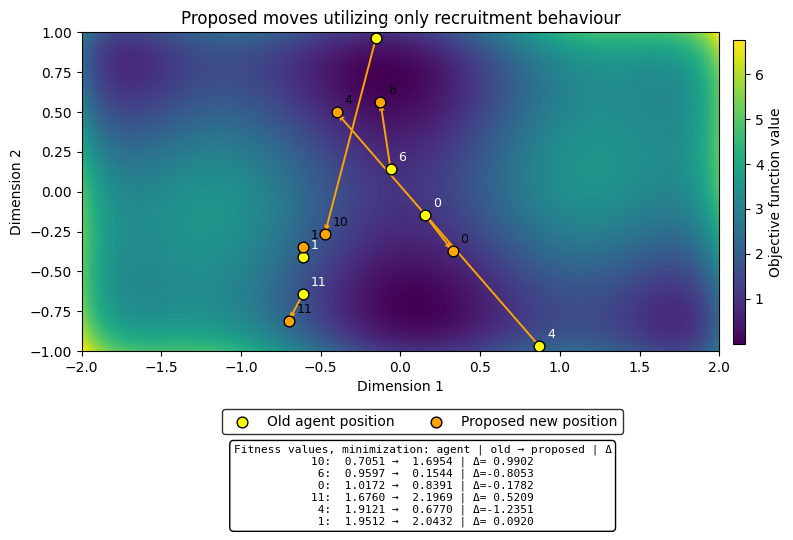

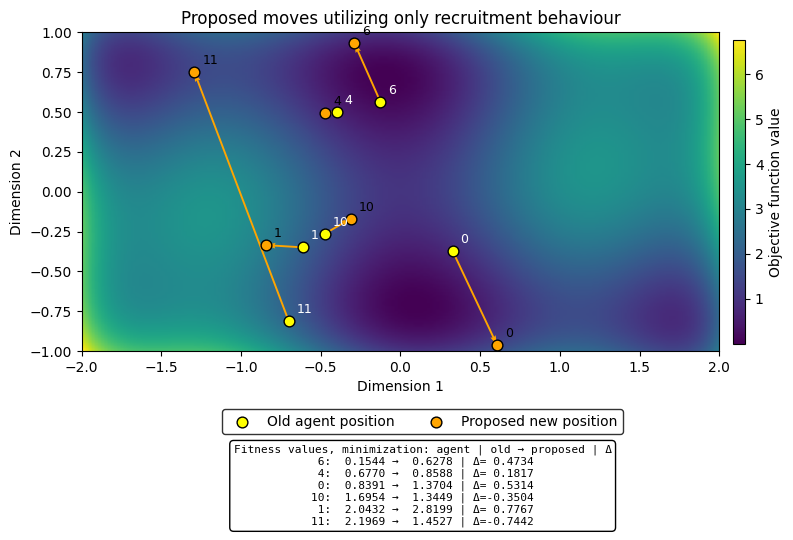

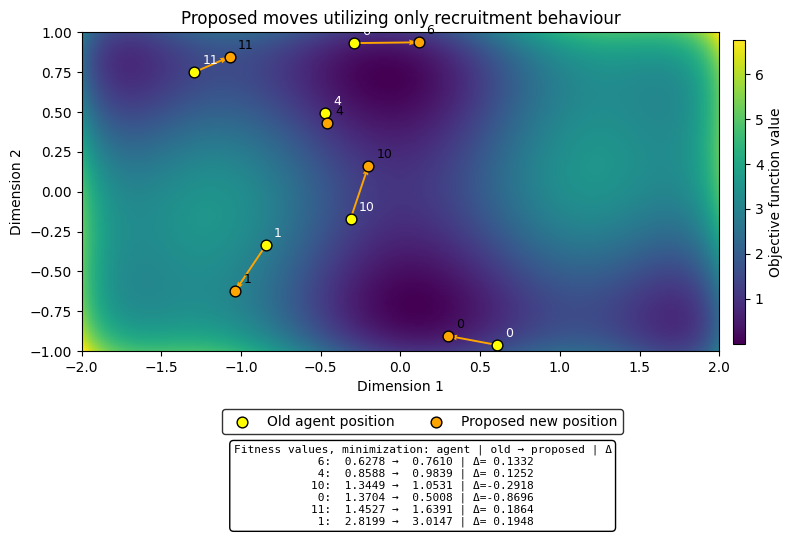

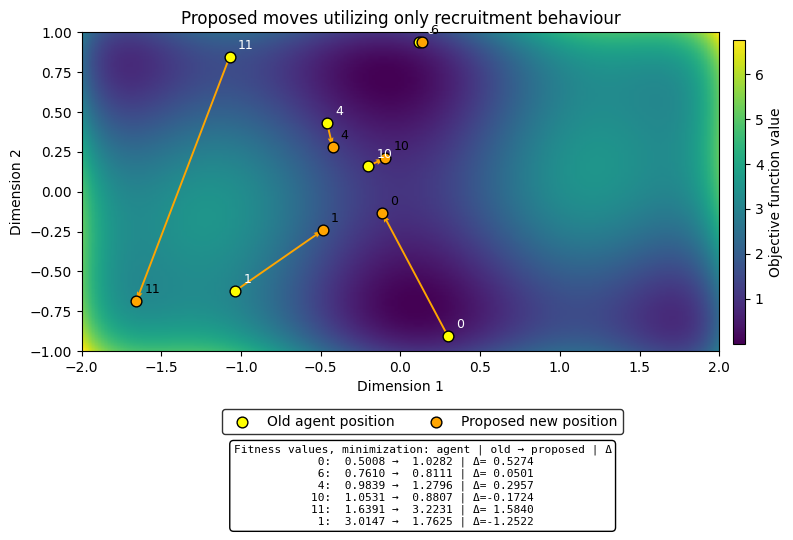

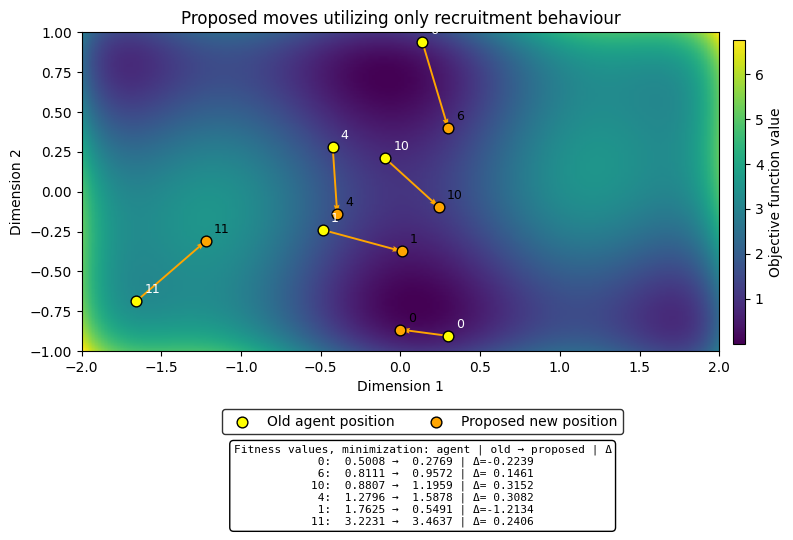

FINAL (debug loop) sorted IDs: [ 1  4  0 10  6 11]
FINAL (debug loop) sorted fit: [0.10560393 0.11514074 1.7002078  0.42314428 0.89568996 2.6138368 ]


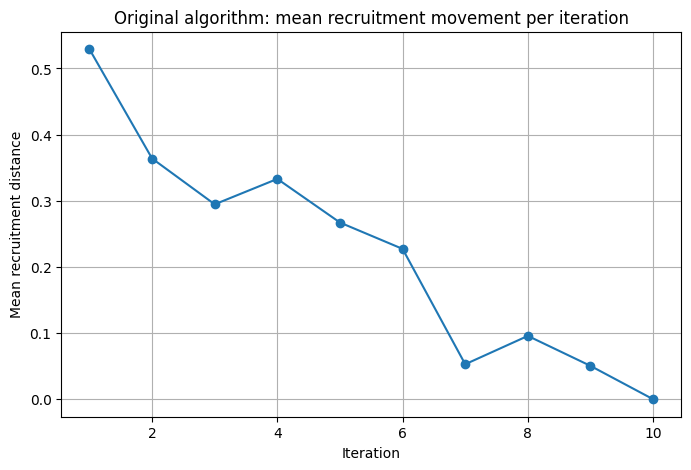

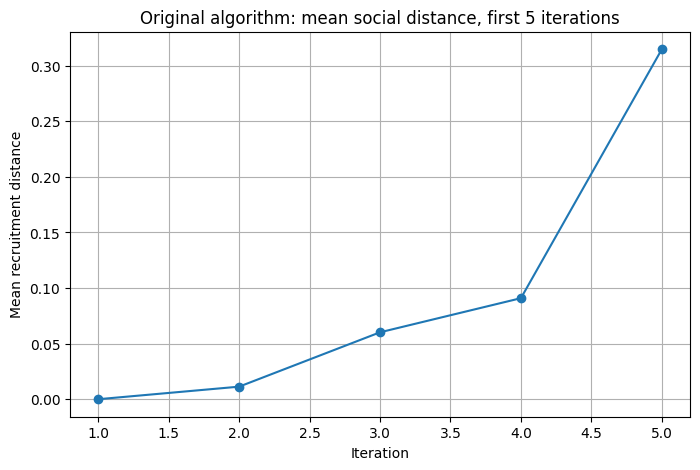

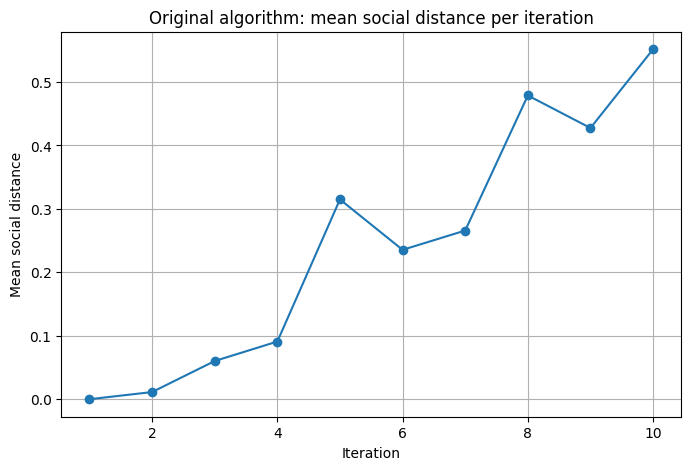

In [24]:
agents_dbg = agents_init
key_dbg = random.PRNGKey(311)
T = 10

bounds = jnp.stack([lo,hi],axis=1)
xmin, xmax = float(bounds[0,0]), float(bounds[0,1])
ymin, ymax = float(bounds[1,0]), float(bounds[1,1])


# Heatmap
res = 200
x = jnp.linspace(bounds[0,0],bounds[0,1],res)
y = jnp.linspace(bounds[1,0],bounds[1,1],res)
xg, yg = jnp.meshgrid(x,y)

grid_points = jnp.stack([xg.reshape(-1),yg.reshape(-1)],axis=1)
Z = evaluate_positions(grid_points,objective_fn).reshape(res,res)
Z_np = np.array(Z)


# Mean distances
mean_recruitment_dist_per_iter = []
mean_social_dist_per_iter = []


# Figures folder
figures_dir = Path("Figures")
figures_dir.mkdir(exist_ok=True)

num_saved_iterations = 5

for t0 in range(T):
    t_iter = jnp.int32(t0 + 1)

    # Sort for ranking
    agents_sorted, _ = Forager.sort_agents_by_fitness(agents_dbg)

    pos_parent = agents_sorted.state.content["pos"]
    fit_parent = agents_sorted.state.content["fit"]
    ids_parent = agents_sorted.id

    k_t = cosine_k(t_iter,T)

    key_dbg, pos_offspring, recruitment_step, social_step = generate_agent_positions(
        key_dbg,pos_parent,lo,hi,k_t
    )

    # Movement distances
    recruitment_dist = jnp.linalg.norm(recruitment_step,axis=1)
    social_dist = jnp.linalg.norm(social_step,axis=1)

    mean_recruitment_dist_per_iter.append(float(jnp.mean(recruitment_dist)))
    mean_social_dist_per_iter.append(float(jnp.mean(social_dist)))

    fit_offspring = evaluate_positions(pos_offspring,objective_fn)

    # Acceptance for population update
    key_dbg, accept = acceptance_rule_mask(key_dbg,fit_parent=fit_parent,fit_offspring=fit_offspring,t=t_iter)

    P = np.array(pos_parent)
    O = np.array(pos_offspring)
    d = O - P

    ids_np = np.array(ids_parent)
    fit_parent_np = np.array(fit_parent)
    fit_offspring_np = np.array(fit_offspring)

    # First five iterations
    if t0 < num_saved_iterations:
        fig = plt.figure(figsize=(8.8,6.8))

        gs = fig.add_gridspec(nrows=2,ncols=1,height_ratios=[4.2,1.45],hspace=0.10)

        ax = fig.add_subplot(gs[0])
        info_ax = fig.add_subplot(gs[1])
        info_ax.axis("off")

        # Heatmap
        heat_map = ax.imshow(Z_np,extent=[xmin,xmax,ymin,ymax],origin="lower",aspect="equal")

        cbar = fig.colorbar(heat_map,ax=ax,pad=0.02,shrink=0.82,fraction=0.045,aspect=25)
        cbar.set_label("Objective function value")

        # Agent positions
        old_scatter = ax.scatter(
            P[:,0],P[:,1],
            s=60,color="yellow",edgecolors="black",
            label="Old agent position",zorder=3
        )

        new_scatter = ax.scatter(
            O[:,0],O[:,1],
            s=60,color="orange",edgecolors="black",
            label="Proposed new position",zorder=4
        )

        # Movement arrows
        ax.quiver(
            P[:,0],P[:,1],d[:,0],d[:,1],
            angles="xy",scale_units="xy",scale=1,
            color="orange",width=0.003,zorder=2
        )

        # Parent labels
        for i in range(P.shape[0]):
            ax.text(
                float(P[i,0]) + 0.05,
                float(P[i,1]) + 0.05,
                str(int(ids_np[i])),
                fontsize=9,color="white",zorder=5
            )

        # Offspring labels
        for i in range(O.shape[0]):
            ax.text(
                float(O[i,0]) + 0.05,
                float(O[i,1]) + 0.05,
                str(int(ids_np[i])),
                fontsize=9,color="black",zorder=5
            )

        # Formatting
        ax.set_xlim(xmin,xmax)
        ax.set_ylim(ymin,ymax)
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")
        ax.set_title("Proposed moves utilizing only recruitment behaviour")
        ax.set_aspect("equal",adjustable="box")
        ax.grid(False)

        # Legend
        info_ax.legend(
            handles=[old_scatter,new_scatter],
            labels=["Old agent position","Proposed new position"],
            loc="upper center",
            bbox_to_anchor=(0.5,1.00),
            ncol=2,
            frameon=True,
            facecolor="white",
            edgecolor="black",
            fontsize=10
        )

        # Fitness values
        fitness_lines = ["Fitness values, minimization: agent | old → proposed | Δ"]

        for i in range(len(ids_np)):
            old_fit = float(fit_parent_np[i])
            new_fit = float(fit_offspring_np[i])
            delta = new_fit - old_fit

            fitness_lines.append(
                f"{int(ids_np[i]):>2}: {old_fit: .4f} → {new_fit: .4f} | Δ={delta: .4f}"
            )

        fitness_text = "\n".join(fitness_lines)

        info_ax.text(
            0.5,0.02,fitness_text,
            ha="center",
            va="bottom",
            fontsize=8,
            family="monospace",
            transform=info_ax.transAxes,
            bbox=dict(facecolor="white",edgecolor="black",boxstyle="round,pad=0.35")
        )

        # Saving SVG
        output_path = figures_dir / f"recruitment_proposed_move_iter_{int(t_iter)}.svg"

        fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.08)

        plt.show()

    # Update population
    agents_dbg = apply_acceptance_update(agents_sorted,pos_offspring=pos_offspring,fit_offspring=fit_offspring,accept=accept)


# Final output
fit_final = agents_dbg.state.content["fit"]
ids_final = agents_dbg.id

print("FINAL (debug loop) sorted IDs:",np.array(ids_final))
print("FINAL (debug loop) sorted fit:",np.array(fit_final))


# Mean recruitment distance
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(np.arange(1,T + 1),mean_recruitment_dist_per_iter,marker="o")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean recruitment distance")
ax.set_title("Original algorithm: mean recruitment movement per iteration")
ax.grid(True)

output_path = figures_dir / "mean_recruitment_distance_full_process.svg"
fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.05)
plt.show()


# Mean social distance for first five iterations
first_n = min(num_saved_iterations,T)

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(np.arange(1,first_n + 1),mean_social_dist_per_iter[:first_n],marker="o")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean recruitment distance")
ax.set_title("Original algorithm: mean social distance, first 5 iterations")
ax.grid(True)

output_path = figures_dir / "mean_social_distance_first_5_iterations.svg"

fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.05)

plt.show()


# Mean social distance
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(np.arange(1,T + 1),mean_social_dist_per_iter,marker="o")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean social distance")
ax.set_title("Original algorithm: mean social distance per iteration")
ax.grid(True)

output_path = figures_dir / "mean_social_distance_full_process.svg"

fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.05)

plt.show()

# Solial behaviour

Iteration 100 | K(t) = -0.0000 | 1 - K(t) = 1.0000 | mean social distance = 1.5244


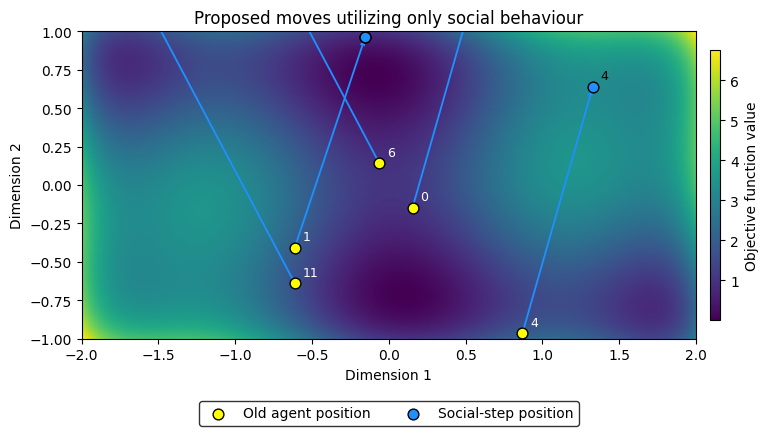

FINAL (debug loop) sorted IDs: [10  6  0 11  4  1]
FINAL (debug loop) sorted fit: [0.70514846 0.95968395 1.0172467  1.6759505  1.9120784  0.70514846]


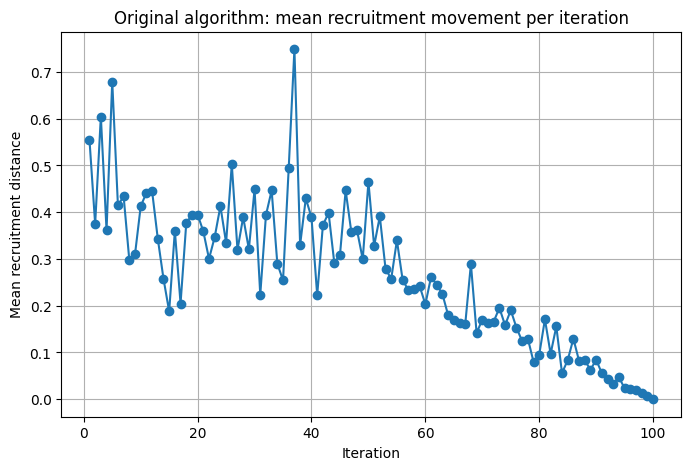

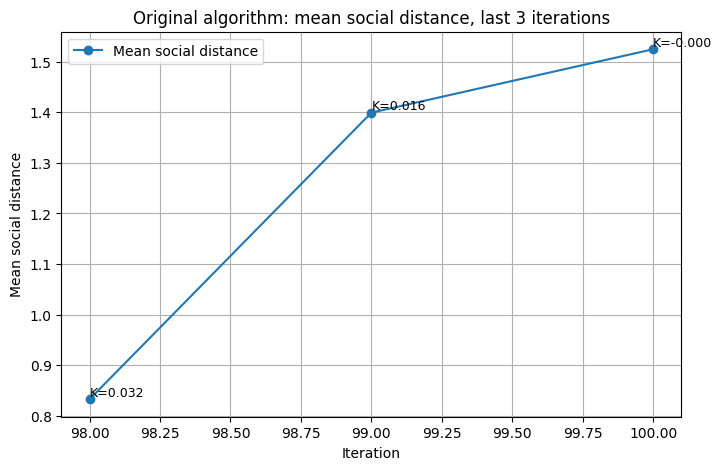

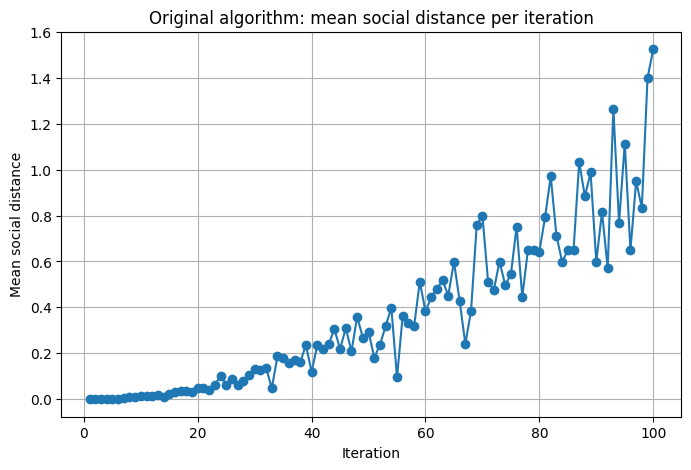

In [26]:
agents_dbg = agents_init
key_dbg = random.PRNGKey(313)
T = 100

bounds = jnp.stack([lo,hi],axis=1)
xmin, xmax = float(bounds[0,0]), float(bounds[0,1])
ymin, ymax = float(bounds[1,0]), float(bounds[1,1])


# Heatmap
res = 200
x = jnp.linspace(bounds[0,0],bounds[0,1],res)
y = jnp.linspace(bounds[1,0],bounds[1,1],res)
xg, yg = jnp.meshgrid(x,y)

grid_points = jnp.stack([xg.reshape(-1),yg.reshape(-1)],axis=1)
Z = evaluate_positions(grid_points,objective_fn).reshape(res,res)
Z_np = np.array(Z)


# Mean distances
mean_recruitment_dist_per_iter = []
mean_social_dist_per_iter = []
k_value_per_iter = []


# Figures folder
figures_dir = Path("Figures")
figures_dir.mkdir(exist_ok=True)

# Last three social iterations
num_saved_social_iterations = 3
first_saved_t0 = T - num_saved_social_iterations

for t0 in range(T):
    t_iter = jnp.int32(t0 + 1)

    # Sort for ranking
    agents_sorted, _ = Forager.sort_agents_by_fitness(agents_dbg)

    pos_parent = agents_sorted.state.content["pos"]
    fit_parent = agents_sorted.state.content["fit"]
    ids_parent = agents_sorted.id

    k_t = cosine_k(t_iter,T)

    key_dbg, pos_offspring, recruitment_step, social_step = generate_agent_positions(key_dbg,pos_parent,lo,hi,k_t)

    # Movement distances
    recruitment_dist = jnp.linalg.norm(recruitment_step,axis=1)
    social_dist = jnp.linalg.norm(social_step,axis=1)

    mean_recruitment = float(jnp.mean(recruitment_dist))
    mean_social = float(jnp.mean(social_dist))
    k_value = float(k_t)
    social_scale = 1.0 - k_value

    mean_recruitment_dist_per_iter.append(mean_recruitment)
    mean_social_dist_per_iter.append(mean_social)
    k_value_per_iter.append(k_value)

    fit_offspring = evaluate_positions(pos_offspring,objective_fn)

    # Acceptance for population update
    key_dbg, accept = acceptance_rule_mask(key_dbg,fit_parent=fit_parent,fit_offspring=fit_offspring,t=t_iter)

    # Social-only positions
    P = np.array(pos_parent)
    social_step_np = np.array(social_step)
    S = P + social_step_np
    d_social = social_step_np
    ids_np = np.array(ids_parent)

# Last three iterations
if t0 >= first_saved_t0:
    print(
        f"Iteration {int(t_iter)} | "
        f"K(t) = {k_value:.4f} | "
        f"1 - K(t) = {social_scale:.4f} | "
        f"mean social distance = {mean_social:.4f}"
    )

    # Figure
    fig, ax = plt.subplots(figsize=(8.6,4.8),constrained_layout=False)
    fig.subplots_adjust(left=0.09,right=0.88,bottom=0.24,top=0.88)

    # Heatmap
    heat_map = ax.imshow(Z_np,extent=[xmin,xmax,ymin,ymax],origin="lower",aspect="equal")

    cbar = fig.colorbar(heat_map,ax=ax,pad=0.02,shrink=0.88,fraction=0.045,aspect=25)
    cbar.set_label("Objective function value")

    # Agent positions
    old_scatter = ax.scatter(
        P[:,0],P[:,1],
        s=60,color="yellow",edgecolors="black",
        label="Old agent position",zorder=3,clip_on=True
    )

    social_scatter = ax.scatter(
        S[:,0],S[:,1],
        s=60,color="dodgerblue",edgecolors="black",
        label="Social-step position",zorder=4,clip_on=True
    )

    # Social movement arrows
    ax.quiver(
        P[:,0],P[:,1],d_social[:,0],d_social[:,1],
        angles="xy",scale_units="xy",scale=1,
        color="dodgerblue",width=0.003,zorder=2,clip_on=True
    )

    ax.set_xlim(xmin,xmax)
    ax.set_ylim(ymin,ymax)

    # Parent labels
    for i in range(P.shape[0]):
        ax.text(
            float(P[i,0]) + 0.05,
            float(P[i,1]) + 0.05,
            str(int(ids_np[i])),
            fontsize=9,color="white",zorder=5,clip_on=True
        )

    # Social-position labels
    for i in range(S.shape[0]):
        ax.text(
            float(S[i,0]) + 0.05,
            float(S[i,1]) + 0.05,
            str(int(ids_np[i])),
            fontsize=9,color="black",zorder=5,clip_on=True
        )

    # Formatting
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_title("Proposed moves utilizing only social behaviour")
    ax.set_aspect("equal",adjustable="box")
    ax.grid(False)

    # Legend
    ax.legend(
        handles=[old_scatter,social_scatter],
        labels=["Old agent position","Social-step position"],
        loc="upper center",
        bbox_to_anchor=(0.5,-0.18),
        ncol=2,
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fontsize=10
    )

    # Saving SVG
    output_path = figures_dir / f"social_step_move_iter_{int(t_iter)}.svg"

    fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.03)

    plt.show()
    plt.close(fig)

    # Update population
    agents_dbg = apply_acceptance_update(agents_sorted,pos_offspring=pos_offspring,fit_offspring=fit_offspring,accept=accept)


# Final output
fit_final = agents_dbg.state.content["fit"]
ids_final = agents_dbg.id

print("FINAL (debug loop) sorted IDs:",np.array(ids_final))
print("FINAL (debug loop) sorted fit:",np.array(fit_final))


# Mean recruitment distance
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(np.arange(1,T + 1),mean_recruitment_dist_per_iter,marker="o")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean recruitment distance")
ax.set_title("Original algorithm: mean recruitment movement per iteration")
ax.grid(True)

output_path = figures_dir / "mean_recruitment_distance_full_process.svg"

fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.05)

plt.show()


# Mean social distance for last three iterations
last_iters = np.arange(T - num_saved_social_iterations + 1,T + 1)
last_social_values = mean_social_dist_per_iter[-num_saved_social_iterations:]
last_k_values = k_value_per_iter[-num_saved_social_iterations:]

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(last_iters,last_social_values,marker="o",label="Mean social distance")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean social distance")
ax.set_title("Original algorithm: mean social distance, last 3 iterations")
ax.grid(True)

# K(t) labels
for iter_id, social_val, k_val in zip(last_iters,last_social_values,last_k_values):
    ax.text(iter_id,social_val,f"K={k_val:.3f}",fontsize=9,ha="left",va="bottom")

ax.legend()

output_path = figures_dir / "mean_social_distance_last_3_iterations.svg"

fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.05)

plt.show()


# Mean social distance
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(np.arange(1,T + 1),mean_social_dist_per_iter,marker="o")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean social distance")
ax.set_title("Original algorithm: mean social distance per iteration")
ax.grid(True)

output_path = figures_dir / "mean_social_distance_full_process.svg"

fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.05)

plt.show()

# Boundary behaviour

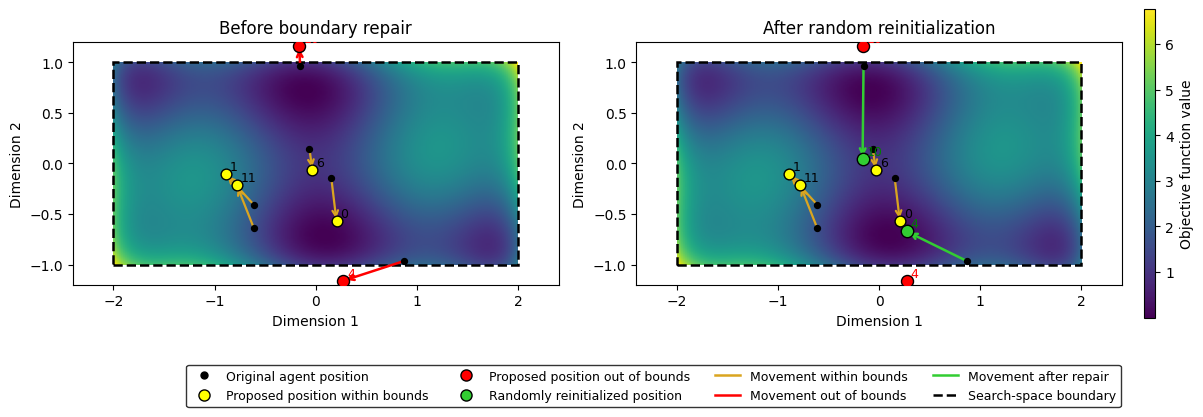

FINAL (debug loop) sorted IDs: [ 4  1  6 10 11  0]
FINAL (debug loop) sorted fit: [0. 0. 0. 0. 0. 0.]


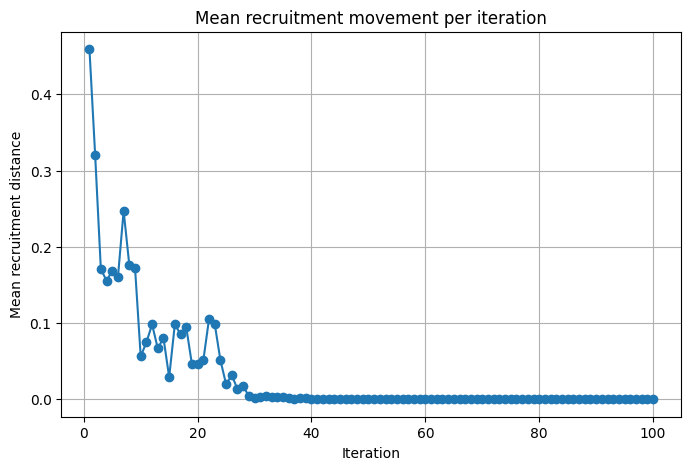

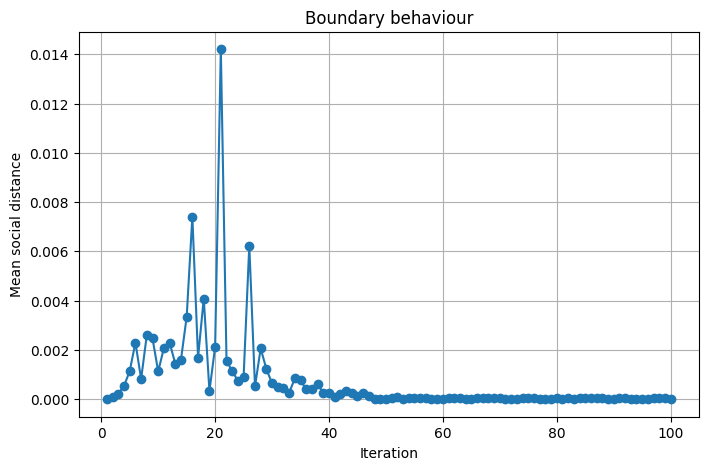

In [ ]:
# Position generation with boundary information
def generate_agent_positions_with_boundary_debug(key,pos_sorted,lo,hi,k):
    """
    Generate new positions for QOS-OFA, while exposing the raw proposed
    position before boundary repair.

    Returns
    -------
    key : updated PRNG key
    pos_offspring : repaired offspring position
    proposed_position_raw : raw proposed position before repair
    oob_mask : numpy bool array, True where raw proposal was out of bounds
    recruitment_step : recruitment movement component
    social_step : social movement component
    """
    N = pos_sorted.shape[0]
    D = pos_sorted.shape[1]

    # Best and worst positions
    x_best = pos_sorted[0]
    x_worst = pos_sorted[-1]

    key, k_r1, k_r2, k_b, k_r = random.split(key,5)

    # Random factors
    r1 = random.uniform(k_r1,shape=(N,D),dtype=pos_sorted.dtype)
    r2 = random.uniform(k_r2,shape=(N,D),dtype=pos_sorted.dtype)
    delta = r1 - r2

    # Agent indices
    j_idx = jnp.arange(N,dtype=jnp.int32)

    # Recruitment indices
    u_b = random.uniform(k_b,shape=(N,),dtype=pos_sorted.dtype)

    b_max = jnp.maximum(j_idx,1)
    b = jnp.floor(u_b * b_max.astype(pos_sorted.dtype)).astype(jnp.int32)
    b = jnp.clip(b,0,N - 1)

    x_b = pos_sorted[b]

    # Social indices
    u_r = random.uniform(k_r,shape=(N,),dtype=pos_sorted.dtype)

    r = jnp.floor(u_r * jnp.asarray(N,dtype=pos_sorted.dtype)).astype(jnp.int32)
    r = jnp.clip(r,0,N - 1)

    x_r = pos_sorted[r]

    # Best agent
    recruitment_best_step = k * delta[0] * (x_best - x_worst)
    social_best_step = jnp.zeros((D,),dtype=pos_sorted.dtype)

    # Other agents
    recruitment_non_best_step = k * delta * (pos_sorted - x_b)
    social_non_best_step = (1.0 - k) * (x_best - x_r)

    is_best = j_idx == 0

    # Recruitment and social steps
    recruitment_step = jnp.where(is_best[:,None],recruitment_best_step[None,:],recruitment_non_best_step)
    social_step = jnp.where(is_best[:,None],social_best_step[None,:],social_non_best_step)

    # Raw proposal
    proposed_position_raw = pos_sorted + recruitment_step + social_step

    # Out-of-bounds mask
    proposed_np = np.array(proposed_position_raw)
    lo_np = np.array(lo)
    hi_np = np.array(hi)

    oob_mask = np.any((proposed_np < lo_np) | (proposed_np > hi_np),axis=1)

    # Boundary repair
    key, pos_offspring = repair_out_of_bounds_uniform(key,proposed_position_raw,lo,hi)

    return key,pos_offspring,proposed_position_raw,oob_mask,recruitment_step,social_step


# Projecting out-of-bounds points for display
def project_oob_points_for_display(O_raw,xmin,xmax,ymin,ymax,margin_frac=0.08):
    """
    For visualization only.

    If a raw proposed point is far outside the boundary, place it just outside
    the visible search-space rectangle. This prevents SVG export from creating
    a huge canvas.
    """
    O_raw = np.array(O_raw)
    O_disp = O_raw.copy()

    margin_x = margin_frac * (xmax - xmin)
    margin_y = margin_frac * (ymax - ymin)

    O_disp[:,0] = np.where(O_raw[:,0] < xmin,xmin - margin_x,np.where(O_raw[:,0] > xmax,xmax + margin_x,O_raw[:,0]))
    O_disp[:,1] = np.where(O_raw[:,1] < ymin,ymin - margin_y,np.where(O_raw[:,1] > ymax,ymax + margin_y,O_raw[:,1]))

    return O_disp


# Boundary behaviour figure
def plot_boundary_behaviour_comparison(P,O_raw,O_repaired,ids_np,oob_mask,Z_np,xmin,xmax,ymin,ymax,figures_dir,t_iter=None):
    """
    Two-panel boundary behaviour figure.

    Left:
        raw proposed positions before boundary repair
        yellow = within bounds
        red    = out of bounds

    Right:
        yellow = within-bound proposals
        red    = original out-of-bound proposals
        green  = randomly reinitialized positions inside the search space
    """
    P = np.array(P)
    O_raw = np.array(O_raw)
    O_repaired = np.array(O_repaired)
    ids_np = np.array(ids_np)
    oob_mask = np.array(oob_mask)

    if not np.any(oob_mask):
        print("No out-of-bounds proposals found in this iteration.")
        return

    in_mask = ~oob_mask

    # Points used for display
    O_display = project_oob_points_for_display(O_raw,xmin=xmin,xmax=xmax,ymin=ymin,ymax=ymax,margin_frac=0.08)

    # Splitting arrays
    P_in = P[in_mask]
    P_oob = P[oob_mask]

    O_in = O_display[in_mask]
    O_oob = O_display[oob_mask]
    O_reinit = O_repaired[oob_mask]

    ids_in = ids_np[in_mask]
    ids_oob = ids_np[oob_mask]

    # Display limits
    pad_x = 0.10 * (xmax - xmin)
    pad_y = 0.10 * (ymax - ymin)

    plot_xmin = xmin - pad_x
    plot_xmax = xmax + pad_x
    plot_ymin = ymin - pad_y
    plot_ymax = ymax + pad_y

    # Figure
    fig, axes = plt.subplots(1,2,figsize=(13.2,5.1),constrained_layout=False)
    ax_left, ax_right = axes

    fig.subplots_adjust(left=0.06,right=0.91,bottom=0.16,top=0.88,wspace=0.16)

    # Base panel
    def draw_base_panel(ax):
        im = ax.imshow(Z_np,extent=[xmin,xmax,ymin,ymax],origin="lower",aspect="equal")

        boundary_rect = Rectangle(
            (xmin,ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linestyle="--",
            linewidth=1.8,
            edgecolor="black",
            zorder=5
        )
        ax.add_patch(boundary_rect)

        ax.set_xlim(plot_xmin,plot_xmax)
        ax.set_ylim(plot_ymin,plot_ymax)
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")
        ax.set_aspect("equal",adjustable="box")
        ax.grid(False)

        return im

    im = draw_base_panel(ax_left)
    draw_base_panel(ax_right)

    # Before boundary repair
    for i in range(len(P_in)):
        ax_left.annotate(
            "",
            xy=(O_in[i,0],O_in[i,1]),
            xytext=(P_in[i,0],P_in[i,1]),
            arrowprops=dict(arrowstyle="->",color="goldenrod",lw=1.6),
            zorder=6
        )

    for i in range(len(P_oob)):
        ax_left.annotate(
            "",
            xy=(O_oob[i,0],O_oob[i,1]),
            xytext=(P_oob[i,0],P_oob[i,1]),
            arrowprops=dict(arrowstyle="->",color="red",lw=1.8),
            zorder=7
        )

    if len(O_in) > 0:
        ax_left.scatter(O_in[:,0],O_in[:,1],s=60,color="yellow",edgecolors="black",zorder=8,clip_on=True)

    ax_left.scatter(O_oob[:,0],O_oob[:,1],s=75,color="red",edgecolors="black",zorder=9,clip_on=True)
    ax_left.scatter(P[:,0],P[:,1],s=18,color="black",zorder=10,clip_on=True)

    for i in range(len(O_in)):
        ax_left.text(float(O_in[i,0]) + 0.04,float(O_in[i,1]) + 0.04,str(int(ids_in[i])),fontsize=9,color="black",zorder=11,clip_on=True)

    for i in range(len(O_oob)):
        ax_left.text(float(O_oob[i,0]) + 0.04,float(O_oob[i,1]) + 0.04,str(int(ids_oob[i])),fontsize=9,color="red",zorder=11,clip_on=True)

    ax_left.set_title("Before boundary repair")

    # After random reinitialization
    for i in range(len(P_in)):
        ax_right.annotate(
            "",
            xy=(O_in[i,0],O_in[i,1]),
            xytext=(P_in[i,0],P_in[i,1]),
            arrowprops=dict(arrowstyle="->",color="goldenrod",lw=1.6),
            zorder=6
        )

    for i in range(len(P_oob)):
        ax_right.annotate(
            "",
            xy=(O_reinit[i,0],O_reinit[i,1]),
            xytext=(P_oob[i,0],P_oob[i,1]),
            arrowprops=dict(arrowstyle="->",color="limegreen",lw=1.8),
            zorder=7
        )

    if len(O_in) > 0:
        ax_right.scatter(O_in[:,0],O_in[:,1],s=60,color="yellow",edgecolors="black",zorder=8,clip_on=True)

    ax_right.scatter(O_oob[:,0],O_oob[:,1],s=75,color="red",edgecolors="black",zorder=9,clip_on=True)
    ax_right.scatter(O_reinit[:,0],O_reinit[:,1],s=80,color="limegreen",edgecolors="black",zorder=10,clip_on=True)
    ax_right.scatter(P[:,0],P[:,1],s=18,color="black",zorder=10,clip_on=True)

    for i in range(len(O_in)):
        ax_right.text(float(O_in[i,0]) + 0.04,float(O_in[i,1]) + 0.04,str(int(ids_in[i])),fontsize=9,color="black",zorder=11,clip_on=True)

    for i in range(len(O_oob)):
        ax_right.text(float(O_oob[i,0]) + 0.04,float(O_oob[i,1]) + 0.04,str(int(ids_oob[i])),fontsize=9,color="red",zorder=11,clip_on=True)
        ax_right.text(float(O_reinit[i,0]) + 0.04,float(O_reinit[i,1]) + 0.04,str(int(ids_oob[i])),fontsize=9,color="green",zorder=11,clip_on=True)

    ax_right.set_title("After random reinitialization")

    # Colorbar
    cbar = fig.colorbar(im,ax=axes,pad=0.02,shrink=0.84,fraction=0.045,aspect=28)
    cbar.set_label("Objective function value")

    # Legend
    legend_handles = [
        Line2D([0],[0],marker="o",color="w",markerfacecolor="black",markeredgecolor="black",markersize=5,label="Original agent position"),
        Line2D([0],[0],marker="o",color="w",markerfacecolor="yellow",markeredgecolor="black",markersize=8,label="Proposed position within bounds"),
        Line2D([0],[0],marker="o",color="w",markerfacecolor="red",markeredgecolor="black",markersize=8,label="Proposed position out of bounds"),
        Line2D([0],[0],marker="o",color="w",markerfacecolor="limegreen",markeredgecolor="black",markersize=8,label="Randomly reinitialized position"),
        Line2D([0],[0],color="goldenrod",lw=1.8,label="Movement within bounds"),
        Line2D([0],[0],color="red",lw=1.8,label="Movement out of bounds"),
        Line2D([0],[0],color="limegreen",lw=1.8,label="Movement after repair"),
        Line2D([0],[0],color="black",linestyle="--",lw=1.8,label="Search-space boundary"),
    ]

    fig.legend(handles=legend_handles,loc="lower center",bbox_to_anchor=(0.5,0.03),ncol=4,frameon=True,facecolor="white",edgecolor="black",fontsize=9)

    # Saving SVG
    figures_dir = Path(figures_dir)
    figures_dir.mkdir(exist_ok=True)

    if t_iter is None:
        filename = "boundary_behaviour_comparison.svg"
    else:
        filename = f"boundary_behaviour_iter_{int(t_iter)}.svg"

    output_path = figures_dir / filename

    fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.03)

    plt.show()
    plt.close(fig)


# Boundary behaviour run
agents_dbg = agents_init
key_dbg = random.PRNGKey(318)
T = 100

bounds = jnp.stack([lo,hi],axis=1)
xmin, xmax = float(bounds[0,0]), float(bounds[0,1])
ymin, ymax = float(bounds[1,0]), float(bounds[1,1])

# Heatmap
res = 200
x = jnp.linspace(bounds[0,0],bounds[0,1],res)
y = jnp.linspace(bounds[1,0],bounds[1,1],res)
xg, yg = jnp.meshgrid(x,y)

grid_points = jnp.stack([xg.reshape(-1),yg.reshape(-1)],axis=1)
Z = evaluate_positions(grid_points,objective_fn).reshape(res,res)
Z_np = np.array(Z)

# Movement distances
mean_recruitment_dist_per_iter = []
mean_social_dist_per_iter = []

# Figures folder
figures_dir = Path("Figures")
figures_dir.mkdir(exist_ok=True)

boundary_plot_saved = False

for t0 in range(T):
    t_iter = jnp.int32(t0 + 1)

    # Sort population
    agents_sorted, _ = Forager.sort_agents_by_fitness(agents_dbg)

    pos_parent = agents_sorted.state.content["pos"]
    fit_parent = agents_sorted.state.content["fit"]
    ids_parent = agents_sorted.id

    k_t = cosine_k(t_iter,T)

    # Generate positions
    (key_dbg,pos_offspring,proposed_position_raw,oob_mask,recruitment_step,social_step) = generate_agent_positions_with_boundary_debug(key_dbg,pos_parent,lo,hi,k_t)

    # Movement distances
    recruitment_dist = jnp.linalg.norm(recruitment_step,axis=1)
    social_dist = jnp.linalg.norm(social_step,axis=1)

    mean_recruitment_dist_per_iter.append(float(jnp.mean(recruitment_dist)))
    mean_social_dist_per_iter.append(float(jnp.mean(social_dist)))

    # First boundary occurrence
    if (not boundary_plot_saved) and np.any(oob_mask):
        plot_boundary_behaviour_comparison(
            P=np.array(pos_parent),
            O_raw=np.array(proposed_position_raw),
            O_repaired=np.array(pos_offspring),
            ids_np=np.array(ids_parent),
            oob_mask=oob_mask,
            Z_np=Z_np,
            xmin=xmin,
            xmax=xmax,
            ymin=ymin,
            ymax=ymax,
            figures_dir=figures_dir,
            t_iter=int(t_iter)
        )

        boundary_plot_saved = True

    # Evaluate offspring
    fit_offspring = evaluate_positions(pos_offspring,objective_fn)

    # Acceptance
    key_dbg, accept = acceptance_rule_mask(key_dbg,fit_parent=fit_parent,fit_offspring=fit_offspring,t=t_iter)

    # Update population
    agents_dbg = apply_acceptance_update(agents_sorted,pos_offspring=pos_offspring,fit_offspring=fit_offspring,accept=accept)

# Final output
fit_final = agents_dbg.state.content["fit"]
ids_final = agents_dbg.id

print("FINAL (debug loop) sorted IDs:",np.array(ids_final))
print("FINAL (debug loop) sorted fit:",np.array(fit_final))

if not boundary_plot_saved:
    print(
        "No out-of-bounds proposed positions were found in this run. "
        "Try increasing T or changing the random seed."
    )


# Mean recruitment distance
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(np.arange(1,T + 1),mean_recruitment_dist_per_iter,marker="o")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean recruitment distance")
ax.set_title("Mean recruitment movement per iteration")
ax.grid(True)

output_path = figures_dir / "mean_recruitment_distance_full_process.svg"

fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.05)

plt.show()


# Mean social distance
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(np.arange(1,T + 1),mean_social_dist_per_iter,marker="o")

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean social distance")
ax.set_title("Boundary behaviour")
ax.grid(True)

output_path = figures_dir / "boundary_behaviour.svg"

fig.savefig(output_path,format="svg",bbox_inches="tight",pad_inches=0.05)

plt.show()

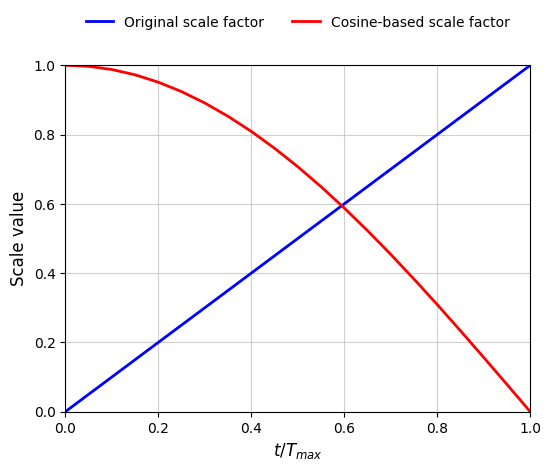

In [29]:
# Scale factor values
n_points = 21

# Normalized iteration: t / Tmax
t_norm = np.linspace(0, 1, n_points)

# Original scale factor: increases linearly from 0 to 1
k_original = t_norm

# Cosine-based scale factor: decreases smoothly from 1 to 0
k_cosine = np.cos((np.pi / 2) * t_norm)

# Plotting
fig, ax = plt.subplots(figsize=(6, 4.5))


ax.plot(t_norm, k_original, color="blue", linewidth=2, label="Original scale factor")
ax.plot(t_norm, k_cosine, color="red", linewidth=2, label="Cosine-based scale factor")

# Formatting
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel(r"$t/T_{max}$", fontsize=12)
ax.set_ylabel("Scale value", fontsize=12)

ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(0, 1, 6))

ax.grid(True, alpha=0.6)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2, frameon=False)

# Saving
figures_dir = Path("Figures")
figures_dir.mkdir(exist_ok=True)

output_path = figures_dir / "scale_factor_comparison.svg"

fig.savefig(output_path, format="svg", bbox_inches="tight", pad_inches=0.02)
plt.show()

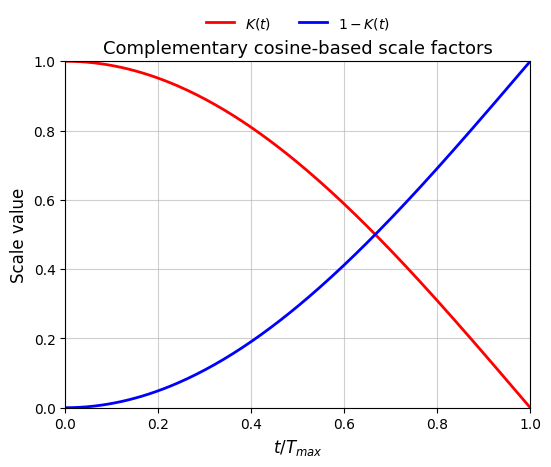

In [30]:
n_points = 200
t_norm = np.linspace(0, 1, n_points)

# K(t): decreases from 1 to 0
K_t = np.cos((np.pi / 2) * t_norm)

# 1 - K(t): increases from 0 to 1
one_minus_K_t = 1 - K_t

# Plotting
fig, ax = plt.subplots(figsize=(6, 4.5))

ax.plot(t_norm, K_t, color="red", linewidth=2, label=r"$K(t)$")

ax.plot(t_norm, one_minus_K_t, color="blue", linewidth=2, label=r"$1 - K(t)$")

# Formatting
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel(r"$t/T_{max}$", fontsize=12)
ax.set_ylabel("Scale value", fontsize=12)

ax.set_title("Complementary cosine-based scale factors", fontsize=13)

ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(0, 1, 6))

ax.grid(True, alpha=0.6)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.17), ncol=2, frameon=False)

# Saving
figures_dir = Path("Figures")
figures_dir.mkdir(exist_ok=True)

output_path = figures_dir / "complementary_cosine_scale_factors.svg"

fig.savefig(output_path, format="svg", bbox_inches="tight", pad_inches=0.02)
plt.show()

Text(0.5, 0.92, 'Six-hump Camelback function used in paper')

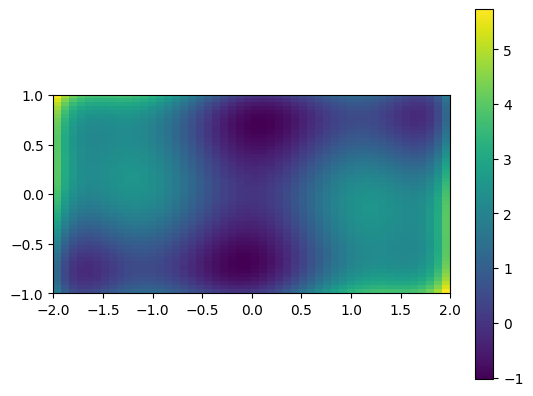

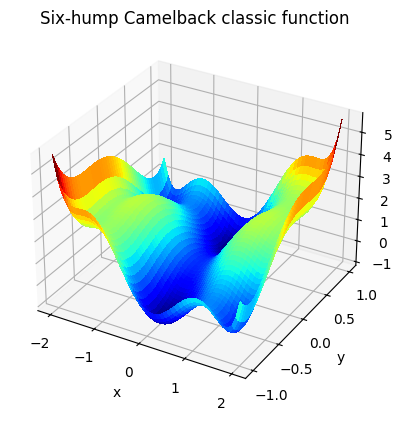

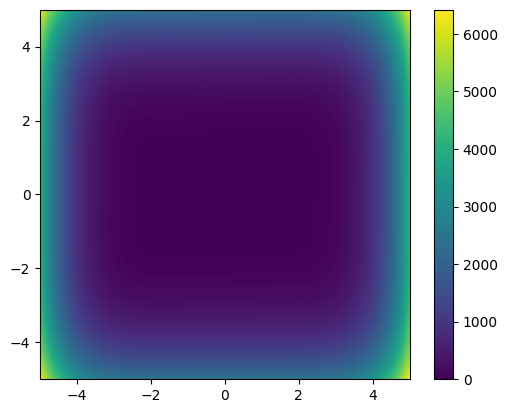

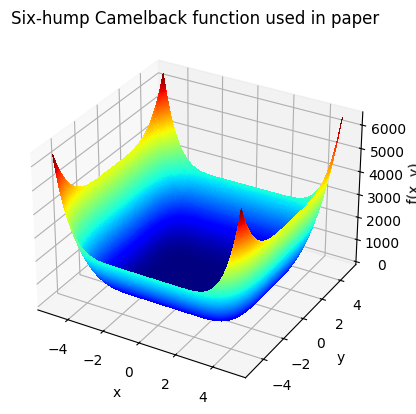

In [ ]:
# Six Hump Camelback  function
def six_hump_classic(x):
    return ((4 - 2.1*x[0]**2 + x[0]**4 / 3.) * x[0]**2 + x[0] * x[1]+ (-4 + 4*x[1]**2) * x[1] **2)
# Making grid
x = np.linspace(-2, 2)
y = np.linspace(-1, 1)
xg, yg = np.meshgrid(x, y)
#Plotting
plt.figure()
plt.imshow(six_hump_classic([xg, yg]), extent=[-2, 2, -1, 1])
plt.colorbar()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xg, yg, six_hump_classic([xg, yg]), rstride=1, cstride=1,cmap=plt.cm.jet, linewidth=0, antialiased=False)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Six-hump Camelback classic function')

# Six Hump Camelback  function
def six_hump(x):
    return ((4 - 2.1*x[0]**2 + x[0]**4 / 3.) * x[0]**2 + x[0] * x[1]+ (-4 + 4*x[1]**2) * x[1] **2)
# Making grid
x = np.linspace(-5, 5, 400)   # add more points (e.g. 400) for smoother plots
y = np.linspace(-5, 5, 400)
xg, yg = np.meshgrid(x, y)
#Plotting
plt.figure()
plt.imshow(six_hump([xg, yg]), extent=[-5, 5, -5, 5])
plt.colorbar()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xg, yg, six_hump([xg, yg]), rstride=1, cstride=1,cmap=plt.cm.jet, linewidth=0, antialiased=False)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Six-hump Camelback function used in paper')
